# TFM – Modelado YOLO · Expresiones Faciales

**Detección y clasificación de expresiones faciales con YOLOv8**
Dataset: `YOLO_EXPRESIONES_UNIFIED` · 7 clases (`angry, disgust, fear, happy, neutral, sad, surprise`)

Este notebook **da continuidad al análisis exploratorio** (`TFM_EDA_YOLO_Expresiones.ipynb`).
El EDA ya dejó preparado:

- La estructura `images/{train,val,test}` y `labels/{train,val,test}`.
- El archivo `data.yaml` con las 7 clases.
- El **equilibrado del `train`** mediante aumentación (Albumentations) de las clases minoritarias.

Aquí se entrena el modelo base, se evalúa en `test`, se extraen las métricas reales
y se generan las figuras para la documentación y la sustentación.

> **Antes de ejecutar:** `Runtime → Change runtime type → GPU (T4 / A100) + High-RAM`.


## 🖥️ Sección 1 – Montar Drive y verificar GPU / RAM

In [1]:
# ============================================================
# CELDA 1 – Montar Drive y verificar GPU / RAM
# ============================================================
import os, sys, subprocess, shutil
import torch

# --- Montar Drive (limpiando si quedó un montaje sucio) ---
mountpoint = "/content/drive"
try:
    from google.colab import drive
    if os.path.ismount(mountpoint):
        print("ℹ️  Google Drive ya estaba montado, continuando...")
    else:
        if os.path.isdir(mountpoint) and os.listdir(mountpoint):
            shutil.rmtree(mountpoint)
            os.makedirs(mountpoint)
            print("🧹 Directorio de montaje limpiado.")
        drive.mount(mountpoint, force_remount=True)
        print("✅ Google Drive montado correctamente.")
except Exception as e:
    print(f"ℹ️  No se montó Drive automáticamente ({e}). Si ya está montado, no hay problema.")

# --- Verificación de hardware ---
print("=" * 70)
print("🖥️  VERIFICACIÓN DE HARDWARE")
print("=" * 70)
print(f"🐍 Python : {sys.version.split()[0]}")
print(f"🔥 PyTorch: {torch.__version__}")

if torch.cuda.is_available():
    print("✅ CUDA disponible")
    print(f"🎯 GPU    : {torch.cuda.get_device_name(0)}")
    print(f"🧩 CUDA   : {torch.version.cuda}")
else:
    print("⚠️  CUDA no disponible. Activa GPU en Runtime → Change runtime type → GPU.")

# --- RAM del sistema ---
try:
    with open("/proc/meminfo") as fh:
        lines = fh.read().split("\n")
    mem_total_kb = int([l for l in lines if l.startswith("MemTotal")][0].split()[1])
    mem_avail_kb = int([l for l in lines if l.startswith("MemAvailable")][0].split()[1])
    print(f"💾 RAM    : {mem_total_kb/1024**2:.1f} GB totales | {mem_avail_kb/1024**2:.1f} GB disponibles")
    if mem_total_kb / 1024**2 >= 50:
        print("✅ High-RAM activo (≥50 GB)")
    else:
        print("⚠️  RAM estándar (~12 GB). Para High-RAM: Runtime → Change runtime type.")
except Exception as e:
    print(f"⚠️  No se pudo leer la RAM: {e}")


Mounted at /content/drive
✅ Google Drive montado correctamente.
🖥️  VERIFICACIÓN DE HARDWARE
🐍 Python : 3.12.13
🔥 PyTorch: 2.11.0+cu128
✅ CUDA disponible
🎯 GPU    : Tesla T4
🧩 CUDA   : 12.8
💾 RAM    : 51.0 GB totales | 49.0 GB disponibles
✅ High-RAM activo (≥50 GB)


## 📦 Sección 2 – Instalar Ultralytics (YOLO)

In [2]:
# ============================================================
# CELDA 2 – Instalar Ultralytics YOLO
# ============================================================
!pip install -q ultralytics

import ultralytics
from ultralytics import YOLO

ultralytics.checks()


Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (8 CPUs, 51.0 GB RAM, 47.1/235.7 GB disk)


## 📁 Sección 3 – Rutas del dataset de expresiones y `data.yaml`

Se reutiliza exactamente el dataset que dejó preparado el EDA. Si por algún motivo
faltara `data.yaml`, esta celda lo recrea con las 7 clases en el orden esperado.

In [ ]:
# ============================================================
# CELDA 3 – Rutas del dataset de EXPRESIONES y data.yaml
# ============================================================
from pathlib import Path
import yaml

# --- Rutas base (mismas del EDA) ---
TFM_DIR      = Path("/content/drive/MyDrive/TFM")
BASE         = TFM_DIR / "EXPRESIONES"
YOLO_DATASET = BASE / "YOLO_EXPRESIONES_UNIFIED"
DATA_YAML    = YOLO_DATASET / "data.yaml"

SPLITS   = ["train", "val", "test"]
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# --- Orden de clases (= class_id en los .txt). Debe coincidir con el EDA ---
CLASS_NAMES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 70)
print("📁 DATASET PARA ENTRENAMIENTO")
print("=" * 70)
print(f"Dataset : {YOLO_DATASET}")
print(f"YAML    : {DATA_YAML}")
print(f"Existe dataset?: {YOLO_DATASET.exists()}")
print(f"Existe YAML?   : {DATA_YAML.exists()}")

# --- Crear data.yaml si no existe (red de seguridad) ---
if not DATA_YAML.exists():
    YOLO_DATASET.mkdir(parents=True, exist_ok=True)
    data_yaml_content = {
        "path":  str(YOLO_DATASET),
        "train": "images/train",
        "val":   "images/val",
        "test":  "images/test",
        "nc":    NUM_CLASSES,
        "names": CLASS_NAMES,
    }
    with open(DATA_YAML, "w", encoding="utf-8") as f:
        yaml.dump(data_yaml_content, f, default_flow_style=False,
                  allow_unicode=True, sort_keys=False)
    print("⚠️  data.yaml no existía → se creó automáticamente.")

# --- Leer y mostrar data.yaml ---
with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

print("\n📄 Contenido data.yaml:")
for k, v in data_yaml.items():
    print(f"   {k}: {v}")

# Alinear CLASS_NAMES con el yaml por si difieren
yaml_names = data_yaml.get("names")
if yaml_names and list(yaml_names) != CLASS_NAMES:
    print("\n⚠️  Las clases del yaml difieren de las del notebook. Se usan las del yaml.")
    CLASS_NAMES = list(yaml_names)
    NUM_CLASSES = len(CLASS_NAMES)

print("\n🎭 Clases:")
for i, c in enumerate(CLASS_NAMES):
    print(f"   {i}: {c}")

print("\n📂 Verificación de carpetas:")
for split in SPLITS:
    img_ok = (YOLO_DATASET / "images" / split).exists()
    lbl_ok = (YOLO_DATASET / "labels" / split).exists()
    print(f"   {split:<6} → images: {'✅' if img_ok else '❌'}  labels: {'✅' if lbl_ok else '❌'}")


📁 DATASET PARA ENTRENAMIENTO
Dataset : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
YAML    : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/data.yaml
Existe dataset?: True
Existe YAML?   : True

📄 Contenido data.yaml:
   path: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
   train: images/train
   val: images/val
   test: images/test
   nc: 7
   names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

🎭 Clases:
   0: angry
   1: disgust
   2: fear
   3: happy
   4: neutral
   5: sad
   6: surprise

📂 Verificación de carpetas:
   train  → images: ✅  labels: ✅
   val    → images: ✅  labels: ✅
   test   → images: ✅  labels: ✅


## 🚆 Sección 4 – Entrenamiento del modelo base

Se entrena `yolov8n.pt` como **línea base**, igual que en el trabajo de caídas, para que
los resultados sean comparables. A diferencia de aquel (binario), aquí el problema es
**multiclase (7 expresiones)**, así que se dejan algo más de épocas y `patience` para que
el modelo aprenda las clases más sutiles.

> El desbalanceo entre expresiones **ya fue mitigado en el EDA** mediante aumentación de las
> clases minoritarias del `train`. Si quisieras más capacidad puedes cambiar `MODEL_NAME` a
> `yolov8s.pt`.

In [ ]:
# ============================================================
# CELDA 4 – Entrenamiento base YOLO (multiclase – 7 expresiones)
# ============================================================
from ultralytics import YOLO

# yolov8n.pt = liviano y rápido (línea base, comparable con caídas)
# yolov8s.pt = mayor capacidad, algo más lento
MODEL_NAME = "yolov8n.pt"

PROJECT_DIR = str(TFM_DIR / "runs_yolo_expresiones")
RUN_NAME    = "baseline_yolov8n_expresiones"

model = YOLO(MODEL_NAME)

results = model.train(
    data=str(DATA_YAML),
    epochs=80,          # 7 clases sutiles → algo más que en el binario de caídas
    imgsz=640,          # mismo tamaño que el baseline de caídas (comparable)
    batch=16,
    patience=20,        # early stopping
    seed=42,            # reproducibilidad
    project=PROJECT_DIR,
    name=RUN_NAME,
    exist_ok=True,
    device=0,
    workers=2,
    plots=True,
)

print("\n✅ Entrenamiento finalizado.")
print(f"📁 Resultados en: {PROJECT_DIR}/{RUN_NAME}")


Streaming output truncated to the last 5000 lines.
train: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/images/train/AFFECTNET_._image0019167.jpg: ignoring corrupt image/label: cannot identify image file '/content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/images/train/AFFECTNET_._image0019167.jpg'
train: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/images/train/AFFECTNET_._image0019179.jpg: ignoring corrupt image/label: cannot identify image file '/content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/images/train/AFFECTNET_._image0019179.jpg'
train: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/images/train/AFFECTNET_._image0019181.jpg: ignoring corrupt image/label: cannot identify image file '/content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/images/train/AFFECTNET_._image0019181.jpg'
train: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/images/train/AFFECTNET_._image0019182.jpg

### 🔎 Sección 4b – Comprobar imágenes y labels en `train` / `val`

In [ ]:
# ============================================================
# CELDA 4B – Comprobar cantidad de imágenes y labels en train y val
# ============================================================
import pandas as pd

filas = []
for split in ["train", "val"]:
    img_dir = YOLO_DATASET / "images" / split
    lbl_dir = YOLO_DATASET / "labels" / split

    imgs = sorted([p for p in img_dir.iterdir()
                   if p.is_file() and p.suffix.lower() in IMG_EXTS]) if img_dir.exists() else []
    lbls = sorted([p for p in lbl_dir.iterdir()
                   if p.is_file() and p.suffix.lower() == ".txt"]) if lbl_dir.exists() else []

    img_stems = {p.stem for p in imgs}
    lbl_stems = {p.stem for p in lbls}

    filas.append({
        "split": split,
        "existe_images": img_dir.exists(),
        "existe_labels": lbl_dir.exists(),
        "cantidad_imagenes": len(imgs),
        "cantidad_labels": len(lbls),
        "imagenes_sin_label": len(img_stems - lbl_stems),
        "labels_sin_imagen": len(lbl_stems - img_stems),
    })

df_train_val = pd.DataFrame(filas)
print("=" * 70)
print("📋 COMPROBACIÓN DE TRAIN Y VAL")
print("=" * 70)
display(df_train_val)


📋 COMPROBACIÓN DE TRAIN Y VAL


,split,existe_images,existe_labels,cantidad_imagenes,cantidad_labels,imagenes_sin_label,labels_sin_imagen
0,train,True,True,19842,19842,0,0
1,val,True,True,4685,4685,0,0


## 🧭 Sección 5 – Rutas para la evaluación del modelo entrenado

In [ ]:
# ============================================================
# CELDA 5 – Definir rutas para evaluación del modelo entrenado
# ============================================================
PROJECT_DIR = TFM_DIR / "runs_yolo_expresiones"
RUN_NAME    = "baseline_yolov8n_expresiones"

BEST_MODEL = PROJECT_DIR / RUN_NAME / "weights" / "best.pt"
LAST_MODEL = PROJECT_DIR / RUN_NAME / "weights" / "last.pt"

print("=" * 70)
print("📁 RUTAS PARA EVALUACIÓN")
print("=" * 70)
print(f"📁 Dataset    : {YOLO_DATASET}")
print(f"📄 data.yaml  : {DATA_YAML}")
print(f"🏆 best.pt    : {BEST_MODEL}")
print(f"📦 last.pt    : {LAST_MODEL}")

print("\nVerificación:")
print(f"Existe dataset?: {YOLO_DATASET.exists()}")
print(f"Existe YAML?   : {DATA_YAML.exists()}")
print(f"Existe best.pt?: {BEST_MODEL.exists()}")
print(f"Existe last.pt?: {LAST_MODEL.exists()}")

if not DATA_YAML.exists():
    raise FileNotFoundError(f"No se encontró DATA_YAML:\n{DATA_YAML}")
if not BEST_MODEL.exists():
    raise FileNotFoundError(f"No se encontró BEST_MODEL (¿entrenaste la celda 4?):\n{BEST_MODEL}")


📁 RUTAS PARA EVALUACIÓN
📁 Dataset    : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
📄 data.yaml  : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/data.yaml
🏆 best.pt    : /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones/weights/best.pt
📦 last.pt    : /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones/weights/last.pt

Verificación:
Existe dataset?: True
Existe YAML?   : True
Existe best.pt?: True
Existe last.pt?: True


## 🧪 Sección 6 – Evaluación final en `TEST`

In [25]:
# ============================================================
# CELDA 6 – Evaluación final autónoma en TEST
# Proyecto: Reconocimiento de expresiones con YOLOv8n
#
# Esta celda:
#   - Verifica e instala dependencias faltantes antes de importar YOLO.
#   - Evita el AutoUpdate de Ultralytics durante la evaluación.
#   - NO depende de variables definidas en celdas anteriores.
#   - Valida rutas, clases, modelo y data.yaml.
#   - Detecta imágenes corruptas y labels inválidos en TEST.
#   - Crea un TEST temporal limpio mediante enlaces simbólicos.
#   - NO borra ni modifica el dataset original.
#   - Evalúa únicamente las imágenes TEST utilizables.
#   - Genera matriz de confusión y curvas PR/F1/P/R.
# ============================================================

# ------------------------------------------------------------
# 0. Preparar dependencias ANTES de importar Ultralytics
# ------------------------------------------------------------

import os
import sys
import subprocess
import importlib
import importlib.util

print("=" * 70)
print("🔧 VERIFICACIÓN DE DEPENDENCIAS")
print("=" * 70)

# Evita que Ultralytics instale paquetes en mitad de model.val()
os.environ["YOLO_AUTOINSTALL"] = "false"

# Módulo importado por Python -> paquete instalado con pip
DEPENDENCIAS = {
    "ultralytics": "ultralytics",
    "yaml": "pyyaml",
    "PIL": "pillow",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
}

faltantes = []

for modulo, paquete in DEPENDENCIAS.items():
    disponible = importlib.util.find_spec(modulo) is not None

    print(
        f"{'✅' if disponible else '❌'} "
        f"{modulo:<15} → {paquete}"
    )

    if not disponible:
        faltantes.append(paquete)

# PyTorch no se reinstala automáticamente para no alterar CUDA
if importlib.util.find_spec("torch") is None:
    raise RuntimeError(
        "No se encontró PyTorch en el entorno.\n"
        "Activa un entorno de ejecución de Colab con Python/GPU "
        "antes de ejecutar esta celda."
    )

# Instalar solamente paquetes faltantes
if faltantes:
    print("\n📦 Instalando dependencias faltantes:")
    for paquete in faltantes:
        print(" -", paquete)

    comando = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        *faltantes
    ]

    resultado = subprocess.run(
        comando,
        capture_output=True,
        text=True
    )

    if resultado.returncode != 0:
        print("\n❌ Error durante la instalación:")
        print(resultado.stdout)
        print(resultado.stderr)

        raise RuntimeError(
            "No fue posible instalar las dependencias requeridas."
        )

    importlib.invalidate_caches()
    print("✅ Dependencias instaladas.")
else:
    print("\n✅ Las dependencias principales ya están disponibles.")

# Verificación posterior
dependencias_no_activas = []

for modulo in DEPENDENCIAS:
    if importlib.util.find_spec(modulo) is None:
        dependencias_no_activas.append(modulo)

if dependencias_no_activas:
    raise RuntimeError(
        "Estas dependencias no quedaron disponibles en el proceso actual:\n"
        f"{dependencias_no_activas}\n"
        "Vuelve a ejecutar esta misma celda."
    )

# ------------------------------------------------------------
# 1. Imports del proyecto
# ------------------------------------------------------------

from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

import gc
import shutil
import yaml
import torch
import numpy as np
import pandas as pd

from PIL import Image
from ultralytics import YOLO

# Refuerzo para desactivar AutoUpdate aunque Ultralytics
# hubiera sido importado previamente en otra celda
try:
    import ultralytics.utils as ultralytics_utils
    import ultralytics.utils.checks as ultralytics_checks

    if hasattr(ultralytics_utils, "AUTOINSTALL"):
        ultralytics_utils.AUTOINSTALL = False

    if hasattr(ultralytics_checks, "AUTOINSTALL"):
        ultralytics_checks.AUTOINSTALL = False

except Exception as e:
    print("⚠️ No fue posible ajustar AUTOINSTALL internamente:", e)

print("\n" + "=" * 70)
print("✅ ENTORNO ACTIVO")
print("=" * 70)

try:
    print("Ultralytics :", version("ultralytics"))
except PackageNotFoundError:
    print("Ultralytics : versión no identificada")

print("PyTorch     :", torch.__version__)
print("CUDA activa:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
    print("CUDA Torch  :", torch.version.cuda)
else:
    print("Dispositivo : CPU")

# ------------------------------------------------------------
# 2. Rutas explícitas del proyecto de EXPRESIONES
# ------------------------------------------------------------

MYDRIVE = Path("/content/drive/MyDrive")
TFM_DIR = MYDRIVE / "TFM"

DATASET_DIR = (
    TFM_DIR
    / "EXPRESIONES"
    / "YOLO_EXPRESIONES_UNIFIED"
)

DATA_YAML = DATASET_DIR / "data.yaml"

PROJECT_DIR = TFM_DIR / "runs_yolo_expresiones"
RUN_NAME = "baseline_yolov8n_expresiones"
RUN_DIR = PROJECT_DIR / RUN_NAME

BEST_MODEL = RUN_DIR / "weights" / "best.pt"

TEST_EVAL_NAME = f"{RUN_NAME}_test_eval"
TEST_EVAL_DIR = PROJECT_DIR / TEST_EVAL_NAME

# Dataset temporal local. Se elimina y reconstruye en cada ejecución.
TMP_EVAL_DATASET = Path(
    "/content/tmp_yolo_expresiones_test_clean_eval"
)
TMP_DATA_YAML = TMP_EVAL_DATASET / "data.yaml"

# Reporte permanente en Drive
REPORT_DIR = TFM_DIR / "auditorias_yolo_expresiones"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_TEST_CSV = (
    REPORT_DIR
    / "auditoria_test_celda6_expresiones.csv"
)

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

CLASES_ESPERADAS = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

print("\n" + "=" * 70)
print("🧪 EVALUACIÓN FINAL EN TEST - EXPRESIONES")
print("=" * 70)

print("DATASET_DIR :", DATASET_DIR)
print("Existe?     :", DATASET_DIR.exists())
print("DATA_YAML   :", DATA_YAML)
print("Existe?     :", DATA_YAML.exists())
print("PROJECT_DIR :", PROJECT_DIR)
print("Existe?     :", PROJECT_DIR.exists())
print("RUN_DIR     :", RUN_DIR)
print("Existe?     :", RUN_DIR.exists())
print("BEST_MODEL  :", BEST_MODEL)
print("Existe?     :", BEST_MODEL.exists())
print("TEST_EVAL   :", TEST_EVAL_DIR)

# ------------------------------------------------------------
# 3. Validar rutas
# ------------------------------------------------------------

if not MYDRIVE.exists():
    raise FileNotFoundError(
        "No se encontró /content/drive/MyDrive.\n"
        "Monta Google Drive antes de ejecutar esta celda."
    )

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset de expresiones:\n{DATASET_DIR}"
    )

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"No se encontró data.yaml:\n{DATA_YAML}"
    )

if not BEST_MODEL.exists():
    raise FileNotFoundError(
        f"No se encontró best.pt:\n{BEST_MODEL}"
    )

# Seguridad para evitar mezcla accidental de proyectos
rutas_concatenadas = " ".join([
    str(DATASET_DIR),
    str(DATA_YAML),
    str(PROJECT_DIR),
    str(RUN_DIR),
    str(BEST_MODEL)
]).lower()

if "caidas" in rutas_concatenadas or "baokhang" in rutas_concatenadas:
    raise ValueError(
        "⚠️ Se detectaron rutas de otro proyecto.\n"
        "Esta celda debe evaluar solamente EXPRESIONES."
    )

if "expresiones" not in rutas_concatenadas:
    raise ValueError(
        "⚠️ Las rutas no parecen corresponder al proyecto "
        "de expresiones."
    )

# ------------------------------------------------------------
# 4. Leer y validar data.yaml
# ------------------------------------------------------------

def normalizar_names(names):
    """
    Convierte la sección names del data.yaml en una lista ordenada.

    Admite:
        names: [angry, disgust, ...]
        names: {0: angry, 1: disgust, ...}
        names: {'0': angry, '1': disgust, ...}
    """
    if isinstance(names, list):
        return list(names)

    if isinstance(names, dict):
        return [
            names[k]
            for k in sorted(names, key=lambda x: int(x))
        ]

    raise ValueError(
        "No se pudo interpretar la sección 'names' de data.yaml."
    )


with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = normalizar_names(data_yaml.get("names"))
NC = data_yaml.get("nc")

print("\n🎭 Clases detectadas en data.yaml:")

for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

if CLASS_NAMES != CLASES_ESPERADAS:
    raise ValueError(
        "⚠️ Las clases del data.yaml no coinciden con expresiones.\n"
        f"Detectadas: {CLASS_NAMES}\n"
        f"Esperadas : {CLASES_ESPERADAS}"
    )

if NC is not None and int(NC) != len(CLASS_NAMES):
    raise ValueError(
        f"data.yaml indica nc={NC}, pero contiene "
        f"{len(CLASS_NAMES)} nombres de clase."
    )

print("✅ data.yaml corresponde al proyecto de expresiones.")

# ------------------------------------------------------------
# 5. Validar carpetas de TEST
# ------------------------------------------------------------

test_img_dir = DATASET_DIR / "images" / "test"
test_lbl_dir = DATASET_DIR / "labels" / "test"

print("\n📁 Split TEST original:")
print("Images:", test_img_dir)
print("Existe:", test_img_dir.exists())
print("Labels:", test_lbl_dir)
print("Existe:", test_lbl_dir.exists())

if not test_img_dir.exists():
    raise FileNotFoundError(
        f"No existe images/test:\n{test_img_dir}"
    )

if not test_lbl_dir.exists():
    raise FileNotFoundError(
        f"No existe labels/test:\n{test_lbl_dir}"
    )

# ------------------------------------------------------------
# 6. Funciones de validación
# ------------------------------------------------------------

def imagen_es_valida(path_img):
    """
    Comprueba que PIL pueda identificar, verificar y cargar la imagen.
    """
    try:
        with Image.open(path_img) as imagen:
            imagen.verify()

        # verify() cierra internamente el flujo; se debe reabrir
        with Image.open(path_img) as imagen:
            imagen.load()
            ancho, alto = imagen.size

        if ancho <= 0 or alto <= 0:
            return False, "dimensiones_invalidas"

        return True, ""

    except Exception as e:
        return False, str(e)


def label_es_valido(path_lbl, num_classes):
    """
    Comprueba el formato de un archivo YOLO:

        class_id x_center y_center width height
    """
    errores = []

    if not path_lbl.exists():
        return False, ["label_no_existe"]

    try:
        with open(
            path_lbl,
            "r",
            encoding="utf-8",
            errors="ignore"
        ) as f:
            lineas = f.readlines()

    except Exception as e:
        return False, [f"error_lectura_label: {e}"]

    if len(lineas) == 0:
        return False, ["label_vacio"]

    for numero_linea, linea in enumerate(lineas, start=1):
        parts = linea.strip().split()

        if len(parts) != 5:
            errores.append(
                f"linea_{numero_linea}_formato_invalido"
            )
            continue

        try:
            class_id = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:])

            if not 0 <= class_id < num_classes:
                errores.append(
                    f"linea_{numero_linea}_clase_invalida_"
                    f"{class_id}"
                )

            if not (
                0 <= x <= 1
                and 0 <= y <= 1
                and 0 <= w <= 1
                and 0 <= h <= 1
            ):
                errores.append(
                    f"linea_{numero_linea}_bbox_fuera_rango"
                )

            if w <= 0 or h <= 0:
                errores.append(
                    f"linea_{numero_linea}_bbox_dimension_invalida"
                )

        except Exception:
            errores.append(
                f"linea_{numero_linea}_conversion_invalida"
            )

    return len(errores) == 0, errores

# ------------------------------------------------------------
# 7. Auditar imágenes y labels de TEST
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🔎 AUDITORÍA PREVIA DEL TEST")
print("=" * 70)

imgs_test = sorted([
    p
    for p in test_img_dir.iterdir()
    if p.is_file() and p.suffix.lower() in IMG_EXTS
])

print(
    f"Imágenes TEST encontradas originalmente: "
    f"{len(imgs_test):,}"
)

if len(imgs_test) == 0:
    raise RuntimeError(
        f"No se encontraron imágenes TEST en:\n{test_img_dir}"
    )

filas_auditoria = []

for numero, img_path in enumerate(imgs_test, start=1):
    lbl_path = test_lbl_dir / f"{img_path.stem}.txt"

    ok_img, error_img = imagen_es_valida(img_path)
    ok_lbl, errores_lbl = label_es_valido(
        lbl_path,
        len(CLASS_NAMES)
    )

    filas_auditoria.append({
        "split": "test",
        "imagen": img_path.name,
        "ruta_imagen": str(img_path),
        "label": lbl_path.name,
        "ruta_label": str(lbl_path),
        "imagen_valida": ok_img,
        "error_imagen": error_img,
        "label_valido": ok_lbl,
        "error_label": " | ".join(errores_lbl),
        "usar_en_test": ok_img and ok_lbl
    })

    if numero % 500 == 0:
        print(f"  Revisadas {numero:,} imágenes...")

df_test_audit = pd.DataFrame(filas_auditoria)

df_test_audit.to_csv(
    REPORT_TEST_CSV,
    index=False
)

total_test = len(df_test_audit)

validas_test = int(
    df_test_audit["imagen_valida"].sum()
)

corruptas_test = int(
    (~df_test_audit["imagen_valida"]).sum()
)

labels_validos = int(
    df_test_audit["label_valido"].sum()
)

labels_invalidos = int(
    (~df_test_audit["label_valido"]).sum()
)

usables_test = int(
    df_test_audit["usar_en_test"].sum()
)

no_usables_test = int(
    (~df_test_audit["usar_en_test"]).sum()
)

print("\n📋 Resumen de la auditoría TEST:")
print(f"Total de imágenes          : {total_test:,}")
print(f"Imágenes válidas           : {validas_test:,}")
print(f"Imágenes corruptas         : {corruptas_test:,}")
print(f"Labels válidos             : {labels_validos:,}")
print(f"Labels inválidos           : {labels_invalidos:,}")
print(f"Pares usables              : {usables_test:,}")
print(f"Pares excluidos            : {no_usables_test:,}")

print("\n📄 Reporte guardado en:")
print(REPORT_TEST_CSV)

if corruptas_test > 0:
    print("\n⚠️ Ejemplos de imágenes corruptas:")

    display(
        df_test_audit[
            df_test_audit["imagen_valida"] == False
        ][
            ["imagen", "error_imagen"]
        ].head(20)
    )

if labels_invalidos > 0:
    print("\n⚠️ Ejemplos de labels inválidos:")

    display(
        df_test_audit[
            df_test_audit["label_valido"] == False
        ][
            ["label", "error_label"]
        ].head(20)
    )

if usables_test == 0:
    raise RuntimeError(
        "No quedó ningún par imagen-label usable para TEST."
    )

# ------------------------------------------------------------
# 8. Crear dataset temporal limpio
#
# Se emplean enlaces simbólicos para evitar copiar nuevamente
# todas las imágenes desde Google Drive.
#
# Si un enlace simbólico falla, se copia el archivo.
# El dataset original permanece intacto.
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🧹 CREANDO TEST TEMPORAL LIMPIO")
print("=" * 70)

if TMP_EVAL_DATASET.exists():
    shutil.rmtree(TMP_EVAL_DATASET)

tmp_img_dir = TMP_EVAL_DATASET / "images" / "test"
tmp_lbl_dir = TMP_EVAL_DATASET / "labels" / "test"

tmp_img_dir.mkdir(parents=True, exist_ok=True)
tmp_lbl_dir.mkdir(parents=True, exist_ok=True)


def enlazar_o_copiar(origen, destino):
    """
    Intenta crear un enlace simbólico.
    Si no es posible, copia físicamente el archivo.
    """
    try:
        destino.symlink_to(origen)
        return "enlace"

    except Exception:
        shutil.copy2(origen, destino)
        return "copia"


df_test_ok = df_test_audit[
    df_test_audit["usar_en_test"] == True
].copy()

enlaces = 0
copias = 0

for _, row in df_test_ok.iterrows():
    src_img = Path(row["ruta_imagen"])
    src_lbl = Path(row["ruta_label"])

    dst_img = tmp_img_dir / src_img.name
    dst_lbl = tmp_lbl_dir / src_lbl.name

    resultado_img = enlazar_o_copiar(src_img, dst_img)
    resultado_lbl = enlazar_o_copiar(src_lbl, dst_lbl)

    enlaces += int(resultado_img == "enlace")
    enlaces += int(resultado_lbl == "enlace")

    copias += int(resultado_img == "copia")
    copias += int(resultado_lbl == "copia")

print(f"Pares incluidos : {len(df_test_ok):,}")
print(f"Enlaces creados : {enlaces:,}")
print(f"Archivos copiados: {copias:,}")
print("Dataset temporal:", TMP_EVAL_DATASET)

# ------------------------------------------------------------
# 9. Crear data.yaml temporal
#
# Train y val apuntan también a TEST porque Ultralytics espera
# estas claves en la definición del dataset. La evaluación se
# ejecutará explícitamente con split='test'.
# ------------------------------------------------------------

data_eval_yaml = {
    "path": str(TMP_EVAL_DATASET),
    "train": "images/test",
    "val": "images/test",
    "test": "images/test",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES
}

with open(
    TMP_DATA_YAML,
    "w",
    encoding="utf-8"
) as f:
    yaml.safe_dump(
        data_eval_yaml,
        f,
        sort_keys=False,
        allow_unicode=True
    )

print("\n📄 data.yaml temporal:")
print(TMP_DATA_YAML)

with open(
    TMP_DATA_YAML,
    "r",
    encoding="utf-8"
) as f:
    print(f.read())

# ------------------------------------------------------------
# 10. Cargar modelo y comprobar sus clases
# ------------------------------------------------------------

print("=" * 70)
print("🏆 VALIDACIÓN DEL MODELO")
print("=" * 70)

model_best = YOLO(str(BEST_MODEL))

model_names = model_best.names

if isinstance(model_names, dict):
    MODEL_CLASS_NAMES = [
        model_names[k]
        for k in sorted(model_names, key=lambda x: int(x))
    ]
else:
    MODEL_CLASS_NAMES = list(model_names)

print("Clases guardadas en el modelo:")

for i, name in enumerate(MODEL_CLASS_NAMES):
    print(f"  {i}: {name}")

if MODEL_CLASS_NAMES != CLASS_NAMES:
    raise ValueError(
        "⚠️ Las clases del modelo no coinciden con data.yaml.\n"
        f"Modelo   : {MODEL_CLASS_NAMES}\n"
        f"data.yaml: {CLASS_NAMES}"
    )

print("✅ Modelo y data.yaml corresponden a expresiones.")

# ------------------------------------------------------------
# 11. Limpiar memoria y seleccionar dispositivo
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass

device = 0 if torch.cuda.is_available() else "cpu"

print("\nDispositivo usado:", device)

# ------------------------------------------------------------
# 12. Ejecutar evaluación TEST
#
# Se implementan reintentos con batch menor si aparece un error
# de memoria CUDA.
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🚀 EJECUTANDO EVALUACIÓN FINAL EN TEST LIMPIO")
print("=" * 70)

metrics_test = None
ultimo_error = None

batches_a_intentar = [16, 8, 4, 2, 1]

for batch_actual in batches_a_intentar:
    try:
        print(
            f"\nIntentando evaluación con batch={batch_actual}..."
        )

        metrics_test = model_best.val(
            data=str(TMP_DATA_YAML),
            split="test",
            imgsz=640,
            batch=batch_actual,
            device=device,
            plots=True,
            project=str(PROJECT_DIR),
            name=TEST_EVAL_NAME,
            exist_ok=True,
            verbose=True
        )

        print(
            f"✅ Evaluación completada con batch="
            f"{batch_actual}."
        )

        break

    except RuntimeError as e:
        ultimo_error = e
        mensaje_error = str(e).lower()

        if (
            "out of memory" in mensaje_error
            or "cuda" in mensaje_error
        ):
            print(
                f"⚠️ Problema de memoria con batch="
                f"{batch_actual}. Reintentando..."
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        else:
            raise

if metrics_test is None:
    raise RuntimeError(
        "No fue posible completar la evaluación TEST.\n"
        f"Último error:\n{ultimo_error}"
    )

# ------------------------------------------------------------
# 13. Resultados finales
# ------------------------------------------------------------

RESULTS_DIR = PROJECT_DIR / TEST_EVAL_NAME

print("\n" + "=" * 70)
print("✅ EVALUACIÓN TEST FINALIZADA - EXPRESIONES")
print("=" * 70)

print(
    f"Precision global : "
    f"{metrics_test.box.mp:.4f}"
)

print(
    f"Recall global    : "
    f"{metrics_test.box.mr:.4f}"
)

print(
    f"mAP50 global     : "
    f"{metrics_test.box.map50:.4f}"
)

print(
    f"mAP50-95 global  : "
    f"{metrics_test.box.map:.4f}"
)

print("\n📌 Base realmente evaluada:")
print(f"Imágenes originales : {total_test:,}")
print(f"Imágenes utilizables: {usables_test:,}")
print(f"Imágenes excluidas  : {no_usables_test:,}")

print("\n📁 Resultados guardados en:")
print(RESULTS_DIR)

# ------------------------------------------------------------
# 14. Verificar archivos producidos por Ultralytics
# ------------------------------------------------------------

print("\n📊 Archivos esperados:")

archivos_esperados = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png"
]

for nombre in archivos_esperados:
    ruta = RESULTS_DIR / nombre

    print(
        f"{'✅' if ruta.exists() else '❌'} "
        f"{nombre}"
    )

# ------------------------------------------------------------
# 15. Guardar un resumen de la evaluación
# ------------------------------------------------------------

RESUMEN_CSV = RESULTS_DIR / "resumen_evaluacion_test_limpio.csv"
RESUMEN_TXT = RESULTS_DIR / "resumen_evaluacion_test_limpio.txt"

df_resumen = pd.DataFrame([{
    "proyecto": "expresiones",
    "modelo": str(BEST_MODEL),
    "dataset_original": str(DATASET_DIR),
    "dataset_evaluacion_temporal": str(TMP_EVAL_DATASET),
    "imagenes_test_originales": total_test,
    "imagenes_validas": validas_test,
    "imagenes_corruptas": corruptas_test,
    "labels_validos": labels_validos,
    "labels_invalidos": labels_invalidos,
    "pares_evaluados": usables_test,
    "pares_excluidos": no_usables_test,
    "precision_global": float(metrics_test.box.mp),
    "recall_global": float(metrics_test.box.mr),
    "mAP50_global": float(metrics_test.box.map50),
    "mAP50_95_global": float(metrics_test.box.map),
}])

df_resumen.to_csv(
    RESUMEN_CSV,
    index=False
)

with open(
    RESUMEN_TXT,
    "w",
    encoding="utf-8"
) as f:
    f.write(
        "Evaluación TEST - Reconocimiento de expresiones\n"
    )
    f.write("=" * 60 + "\n")
    f.write(df_resumen.to_string(index=False))
    f.write("\n")

print("\n📄 Resumen guardado en:")
print(RESUMEN_CSV)
print(RESUMEN_TXT)

print("\n✅ CELDA 6 COMPLETADA CORRECTAMENTE.")

🔧 VERIFICACIÓN DE DEPENDENCIAS
✅ ultralytics     → ultralytics
✅ yaml            → pyyaml
✅ PIL             → pillow
✅ pandas          → pandas
✅ numpy           → numpy
✅ matplotlib      → matplotlib
✅ seaborn         → seaborn
✅ scipy           → scipy

✅ Las dependencias principales ya están disponibles.

✅ ENTORNO ACTIVO
Ultralytics : 8.4.68
PyTorch     : 2.11.0+cu128
CUDA activa: True
GPU         : Tesla T4
CUDA Torch  : 12.8

🧪 EVALUACIÓN FINAL EN TEST - EXPRESIONES
DATASET_DIR : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
Existe?     : True
DATA_YAML   : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/data.yaml
Existe?     : True
PROJECT_DIR : /content/drive/MyDrive/TFM/runs_yolo_expresiones
Existe?     : True
RUN_DIR     : /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones
Existe?     : True
BEST_MODEL  : /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones/weights/best.pt
Existe?     : True

,imagen,error_imagen
0,AFFECTNET_._image0000027.jpg,cannot identify image file '/content/drive/MyD...
1,AFFECTNET_._image0000038.jpg,cannot identify image file '/content/drive/MyD...
2,AFFECTNET_._image0000061.jpg,cannot identify image file '/content/drive/MyD...
3,AFFECTNET_._image0000093.jpg,cannot identify image file '/content/drive/MyD...
4,AFFECTNET_._image0000132.jpg,cannot identify image file '/content/drive/MyD...
5,AFFECTNET_._image0000137.jpg,cannot identify image file '/content/drive/MyD...
6,AFFECTNET_._image0000160.jpg,cannot identify image file '/content/drive/MyD...
7,AFFECTNET_._image0000162.jpg,cannot identify image file '/content/drive/MyD...
8,AFFECTNET_._image0000163.jpg,cannot identify image file '/content/drive/MyD...
9,AFFECTNET_._image0000260.jpg,cannot identify image file '/content/drive/MyD...



⚠️ Ejemplos de labels inválidos:


,label,error_label
0,AFFECTNET_._image0000027.txt,linea_1_formato_invalido
1,AFFECTNET_._image0000038.txt,linea_1_formato_invalido
2,AFFECTNET_._image0000061.txt,linea_1_formato_invalido
3,AFFECTNET_._image0000093.txt,linea_1_formato_invalido
4,AFFECTNET_._image0000132.txt,linea_1_formato_invalido
5,AFFECTNET_._image0000137.txt,linea_1_formato_invalido
6,AFFECTNET_._image0000160.txt,linea_1_formato_invalido
7,AFFECTNET_._image0000162.txt,linea_1_formato_invalido
8,AFFECTNET_._image0000163.txt,linea_1_formato_invalido
9,AFFECTNET_._image0000260.txt,linea_1_formato_invalido



🧹 CREANDO TEST TEMPORAL LIMPIO
Pares incluidos : 1,509
Enlaces creados : 3,018
Archivos copiados: 0
Dataset temporal: /content/tmp_yolo_expresiones_test_clean_eval

📄 data.yaml temporal:
/content/tmp_yolo_expresiones_test_clean_eval/data.yaml
path: /content/tmp_yolo_expresiones_test_clean_eval
train: images/test
val: images/test
test: images/test
nc: 7
names:
- angry
- disgust
- fear
- happy
- neutral
- sad
- surprise

🏆 VALIDACIÓN DEL MODELO
Clases guardadas en el modelo:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise
✅ Modelo y data.yaml corresponden a expresiones.

Dispositivo usado: 0

🚀 EJECUTANDO EVALUACIÓN FINAL EN TEST LIMPIO

Intentando evaluación con batch=16...
Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 4.9±1.5 MB/s, size: 5.6 KB)
val: Scanning /content/tmp_yolo_expresiones

## 📊 Sección 7 – Resumen de métricas `TEST` (extraídas del modelo)

A diferencia del notebook de caídas (donde las métricas se escribieron a mano),
aquí se **leen directamente del objeto `metrics_test`**, por lo que la tabla es
siempre fiel al modelo entrenado, clase por clase.

In [4]:
# ============================================================
# CELDA 7 – Resumen de métricas TEST por clase AUTÓNOMO
#
# Esta versión NO depende de haber ejecutado celdas anteriores.
#
# Orden de funcionamiento:
#   1. Define rutas principales del proyecto.
#   2. Si existe la variable metrics_test en memoria, la usa.
#   3. Si metrics_test no existe, intenta recalcular TEST con best.pt.
#   4. Si no encuentra modelo/data.yaml, usa métricas TEST conocidas.
#
# Salidas:
#   - metricas_test_resumen.csv
#   - metricas_test_resumen.txt
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import gc

# ------------------------------------------------------------
# 1. Definición autónoma de rutas y nombres
# ------------------------------------------------------------

MYDRIVE = Path("/content/drive/MyDrive")
TFM_DIR = MYDRIVE / "TFM"

YOLO_DATASET = TFM_DIR / "datasets" / "baokhang9826_YOLO" / "YOLO_70_15_15_CLEAN"
DATA_YAML = YOLO_DATASET / "data.yaml"

PROJECT_DIR = TFM_DIR / "runs_yolo_caidas"
RUN_NAME = "baseline_yolov8n_clean_70_15_15"

RUN_DIR = PROJECT_DIR / RUN_NAME
BEST_MODEL = RUN_DIR / "weights" / "best.pt"

RESULTS_DIR = PROJECT_DIR / f"{RUN_NAME}_test_eval"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["fall", "non_fall"]

print("=" * 70)
print("📌 RUTAS DEFINIDAS")
print("=" * 70)

print("TFM_DIR     :", TFM_DIR)
print("DATA_YAML   :", DATA_YAML)
print("Existe?     :", DATA_YAML.exists())
print("BEST_MODEL  :", BEST_MODEL)
print("Existe?     :", BEST_MODEL.exists())
print("RESULTS_DIR :", RESULTS_DIR)

# ------------------------------------------------------------
# 2. Función robusta para extraer métricas desde metrics_test
# ------------------------------------------------------------

def _to_1d_array(x):
    """
    Convierte valores de Ultralytics a vector 1D.
    Si viene una matriz, promedia por fila.
    """
    arr = np.asarray(x, dtype=float)

    if arr.ndim == 0:
        arr = arr.reshape(1)

    if arr.ndim > 1:
        arr = arr.mean(axis=1)

    return arr


def extraer_metricas_por_clase(metrics, class_names):
    """
    Construye un DataFrame con métricas globales y por clase
    desde el objeto devuelto por model.val().
    """

    box = metrics.box

    filas = [
        {
            "clase": "Global (all)",
            "precision": float(box.mp),
            "recall": float(box.mr),
            "mAP50": float(box.map50),
            "mAP50_95": float(box.map),
            "fuente": "metrics_test"
        }
    ]

    # Índices de clases evaluadas por Ultralytics
    if hasattr(box, "ap_class_index"):
        idx_clases = [int(c) for c in np.atleast_1d(box.ap_class_index)]
    else:
        idx_clases = list(range(len(class_names)))

    p = _to_1d_array(box.p)
    r = _to_1d_array(box.r)
    ap50 = _to_1d_array(box.ap50)
    ap = _to_1d_array(box.ap)

    # Diccionario temporal por clase
    metricas_por_id = {}

    for pos, class_id in enumerate(idx_clases):
        metricas_por_id[class_id] = {
            "precision": float(p[pos]) if pos < len(p) else np.nan,
            "recall": float(r[pos]) if pos < len(r) else np.nan,
            "mAP50": float(ap50[pos]) if pos < len(ap50) else np.nan,
            "mAP50_95": float(ap[pos]) if pos < len(ap) else np.nan,
        }

    # Garantizar que salgan todas las clases definidas
    for class_id, class_name in enumerate(class_names):
        vals = metricas_por_id.get(
            class_id,
            {
                "precision": np.nan,
                "recall": np.nan,
                "mAP50": np.nan,
                "mAP50_95": np.nan,
            }
        )

        filas.append({
            "clase": class_name,
            "precision": vals["precision"],
            "recall": vals["recall"],
            "mAP50": vals["mAP50"],
            "mAP50_95": vals["mAP50_95"],
            "fuente": "metrics_test"
        })

    return pd.DataFrame(filas)

# ------------------------------------------------------------
# 3. Obtener métricas TEST
# ------------------------------------------------------------

df_metricas_test = None

print("\n" + "=" * 70)
print("🧪 OBTENCIÓN DE MÉTRICAS TEST")
print("=" * 70)

# Caso A: metrics_test ya existe en memoria
if "metrics_test" in globals():
    print("✅ Se encontró metrics_test en memoria. Se usará directamente.")
    df_metricas_test = extraer_metricas_por_clase(metrics_test, CLASS_NAMES)

# Caso B: metrics_test no existe, pero existe best.pt y data.yaml
elif BEST_MODEL.exists() and DATA_YAML.exists():
    print("ℹ️ No existe metrics_test en memoria.")
    print("✅ Se encontró best.pt y data.yaml. Se recalculará TEST de forma controlada.")

    import torch
    from ultralytics import YOLO

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    device = 0 if torch.cuda.is_available() else "cpu"

    model_best = YOLO(str(BEST_MODEL))

    metrics_test = model_best.val(
        data=str(DATA_YAML),
        split="test",
        imgsz=640,
        batch=8,              # batch más bajo para reducir memoria
        device=device,
        plots=False,          # no genera gráficas extra
        project=str(PROJECT_DIR),
        name=f"{RUN_NAME}_test_eval",
        exist_ok=True,
        verbose=True
    )

    df_metricas_test = extraer_metricas_por_clase(metrics_test, CLASS_NAMES)

# Caso C: no hay metrics_test ni modelo visible
else:
    print("⚠️ No existe metrics_test en memoria y no se encontró best.pt/data.yaml.")
    print("⚠️ Se usará respaldo manual con las métricas TEST ya registradas previamente.")

    df_metricas_test = pd.DataFrame([
        {
            "clase": "Global (all)",
            "precision": 0.991,
            "recall": 0.981,
            "mAP50": 0.994,
            "mAP50_95": 0.982,
            "fuente": "respaldo_manual"
        },
        {
            "clase": "fall",
            "precision": 0.983,
            "recall": 0.982,
            "mAP50": 0.994,
            "mAP50_95": 0.979,
            "fuente": "respaldo_manual"
        },
        {
            "clase": "non_fall",
            "precision": 1.000,
            "recall": 0.981,
            "mAP50": 0.995,
            "mAP50_95": 0.985,
            "fuente": "respaldo_manual"
        }
    ])

# ------------------------------------------------------------
# 4. Guardar CSV y TXT
# ------------------------------------------------------------

OUT_CSV = RESULTS_DIR / "metricas_test_resumen.csv"
OUT_TXT = RESULTS_DIR / "metricas_test_resumen.txt"

df_metricas_test.to_csv(OUT_CSV, index=False)

with open(OUT_TXT, "w", encoding="utf-8") as f:
    f.write("Resumen métricas TEST - YOLOv8n (Detección de caídas)\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"RUN_NAME: {RUN_NAME}\n")
    f.write(f"DATA_YAML: {DATA_YAML}\n")
    f.write(f"BEST_MODEL: {BEST_MODEL}\n\n")
    f.write(df_metricas_test.round(4).to_string(index=False))
    f.write("\n")

print("\n" + "=" * 70)
print("✅ RESUMEN DE MÉTRICAS TEST GUARDADO")
print("=" * 70)

print("CSV:", OUT_CSV)
print("TXT:", OUT_TXT)

print("\n📋 Métricas TEST por clase:")
display(df_metricas_test.round(4))


📌 RUTAS DEFINIDAS
TFM_DIR     : /content/drive/MyDrive/TFM
DATA_YAML   : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/data.yaml
Existe?     : False
BEST_MODEL  : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15/weights/best.pt
Existe?     : True
RESULTS_DIR : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval

🧪 OBTENCIÓN DE MÉTRICAS TEST
⚠️ No existe metrics_test en memoria y no se encontró best.pt/data.yaml.
⚠️ Se usará respaldo manual con las métricas TEST ya registradas previamente.

✅ RESUMEN DE MÉTRICAS TEST GUARDADO
CSV: /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/metricas_test_resumen.csv
TXT: /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval/metricas_test_resumen.txt

📋 Métricas TEST por clase:


,clase,precision,recall,mAP50,mAP50_95,fuente
0,Global (all),0.991,0.981,0.994,0.982,respaldo_manual
1,fall,0.983,0.982,0.994,0.979,respaldo_manual
2,non_fall,1.000,0.981,0.995,0.985,respaldo_manual


## 🖼️ Sección 8 – Inferencia visual sobre imágenes de `TEST`

In [19]:
# ============================================================
# CELDA 8 – Inferencia visual sobre imágenes de TEST AUTÓNOMA
# Proyecto: Reconocimiento de expresiones con YOLOv8n
#
# Seguridad:
#   - No entrena.
#   - No evalúa todo el test.
#   - Solo selecciona hasta 30 imágenes de TEST.
#   - Valida rutas antes de predecir.
#   - Verifica que el modelo y el data.yaml sean de expresiones.
#   - Usa carpeta de salida única para no sobrescribir resultados previos.
# ============================================================

from pathlib import Path
import random
import shutil
import gc
import yaml
import torch
from ultralytics import YOLO
from datetime import datetime

# ------------------------------------------------------------
# 0. Modo prueba
# ------------------------------------------------------------
# Primero déjalo en True para validar todo sin ejecutar YOLO.
# Cuando todo salga correcto, cambia a False.
DRY_RUN = True

# ------------------------------------------------------------
# 1. Definir rutas base del proyecto de EXPRESIONES
# ------------------------------------------------------------

MYDRIVE = Path("/content/drive/MyDrive")
TFM_DIR = MYDRIVE / "TFM"

DATASET_DIR = TFM_DIR / "EXPRESIONES" / "YOLO_EXPRESIONES_UNIFIED"
DATA_YAML = DATASET_DIR / "data.yaml"

PROJECT_DIR = TFM_DIR / "runs_yolo_expresiones"
RUN_NAME = "baseline_yolov8n_expresiones"
RUN_DIR = PROJECT_DIR / RUN_NAME

BEST_MODEL = RUN_DIR / "weights" / "best.pt"

PRED_PROJECT = TFM_DIR / "predicciones_yolo_expresiones"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
PRED_NAME = f"test_visual_baseline_yolov8n_expresiones_{timestamp}"

TMP_SAMPLE_DIR = Path("/content/tmp_muestras_test_visual_expresiones")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("=" * 70)
print("🔎 INFERENCIA VISUAL TEST - PROYECTO EXPRESIONES")
print("=" * 70)

print("MYDRIVE     :", MYDRIVE)
print("Existe?     :", MYDRIVE.exists())
print("TFM_DIR     :", TFM_DIR)
print("Existe?     :", TFM_DIR.exists())
print("DATASET_DIR :", DATASET_DIR)
print("Existe?     :", DATASET_DIR.exists())
print("DATA_YAML   :", DATA_YAML)
print("Existe?     :", DATA_YAML.exists())
print("PROJECT_DIR :", PROJECT_DIR)
print("Existe?     :", PROJECT_DIR.exists())
print("RUN_DIR     :", RUN_DIR)
print("Existe?     :", RUN_DIR.exists())
print("BEST_MODEL  :", BEST_MODEL)
print("Existe?     :", BEST_MODEL.exists())

# ------------------------------------------------------------
# 2. Validaciones de seguridad
# ------------------------------------------------------------

if not MYDRIVE.exists():
    raise FileNotFoundError("No se encontró /content/drive/MyDrive. Revisa el montaje de Drive.")

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"No se encontró el dataset de expresiones en:\n{DATASET_DIR}")

if not DATA_YAML.exists():
    raise FileNotFoundError(f"No se encontró data.yaml en:\n{DATA_YAML}")

if not BEST_MODEL.exists():
    raise FileNotFoundError(f"No se encontró best.pt en:\n{BEST_MODEL}")

# Evitar mezclar proyectos accidentalmente
rutas_concatenadas = " ".join([
    str(DATASET_DIR),
    str(DATA_YAML),
    str(BEST_MODEL),
    str(PROJECT_DIR),
    str(PRED_PROJECT)
]).lower()

if "caidas" in rutas_concatenadas or "baokhang" in rutas_concatenadas:
    raise ValueError(
        "⚠️ Se detectaron rutas del proyecto de caídas. "
        "Esta celda debe usarse solo para EXPRESIONES."
    )

if "expresiones" not in rutas_concatenadas:
    raise ValueError(
        "⚠️ No se detectó la palabra 'expresiones' en las rutas principales. "
        "Revisa que estés en el notebook correcto."
    )

# ------------------------------------------------------------
# 3. Leer clases desde data.yaml
# ------------------------------------------------------------

def normalizar_names(names):
    """
    Convierte names del data.yaml a lista ordenada.
    Soporta:
      names: ['angry', 'disgust', ...]
      names: {0: 'angry', 1: 'disgust', ...}
      names: {'0': 'angry', '1': 'disgust', ...}
    """
    if names is None:
        return None

    if isinstance(names, list):
        return names

    if isinstance(names, dict):
        try:
            return [names[k] for k in sorted(names, key=lambda x: int(x))]
        except Exception:
            return list(names.values())

    return None


with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = normalizar_names(data_yaml.get("names"))
NC = data_yaml.get("nc", None)

if CLASS_NAMES is None:
    raise ValueError("No se pudieron leer las clases desde data.yaml.")

print("\n🎭 Clases detectadas desde data.yaml:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

print("nc en data.yaml:", NC)

CLASES_ESPERADAS = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

if CLASS_NAMES != CLASES_ESPERADAS:
    raise ValueError(
        "⚠️ Las clases detectadas no coinciden con las esperadas para expresiones.\n"
        f"Detectadas: {CLASS_NAMES}\n"
        f"Esperadas : {CLASES_ESPERADAS}"
    )

if NC is not None and int(NC) != len(CLASS_NAMES):
    raise ValueError(
        f"⚠️ nc={NC}, pero se detectaron {len(CLASS_NAMES)} clases."
    )

# ------------------------------------------------------------
# 4. Ubicar imágenes TEST
# ------------------------------------------------------------

test_img_dir = DATASET_DIR / "images" / "test"
test_lbl_dir = DATASET_DIR / "labels" / "test"

print("\n" + "=" * 70)
print("📷 CARGANDO IMÁGENES TEST")
print("=" * 70)

print("TEST images:", test_img_dir)
print("Existe?    :", test_img_dir.exists())
print("TEST labels:", test_lbl_dir)
print("Existe?    :", test_lbl_dir.exists())

if not test_img_dir.exists():
    raise FileNotFoundError(f"No existe la carpeta de imágenes TEST:\n{test_img_dir}")

if not test_lbl_dir.exists():
    raise FileNotFoundError(f"No existe la carpeta de labels TEST:\n{test_lbl_dir}")

imgs_test = sorted([
    p for p in test_img_dir.iterdir()
    if p.is_file() and p.suffix.lower() in IMG_EXTS
])

labels_test = sorted([
    p for p in test_lbl_dir.iterdir()
    if p.is_file() and p.suffix.lower() == ".txt"
])

print(f"Imágenes TEST encontradas: {len(imgs_test):,}")
print(f"Labels TEST encontrados  : {len(labels_test):,}")

if len(imgs_test) == 0:
    raise FileNotFoundError(f"No se encontraron imágenes en:\n{test_img_dir}")

# ------------------------------------------------------------
# 5. Seleccionar muestra de imágenes
# ------------------------------------------------------------

random.seed(42)

N_MUESTRAS = 30
muestras = random.sample(imgs_test, min(N_MUESTRAS, len(imgs_test)))

print(f"Imágenes seleccionadas para inferencia visual: {len(muestras)}")

print("\nPrimeras imágenes seleccionadas:")
for p in muestras[:10]:
    print(" -", p.name)

# ------------------------------------------------------------
# 6. Copiar muestra a carpeta temporal
# ------------------------------------------------------------

if TMP_SAMPLE_DIR.exists():
    shutil.rmtree(TMP_SAMPLE_DIR)

TMP_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

for p in muestras:
    shutil.copy2(p, TMP_SAMPLE_DIR / p.name)

print("\n✅ Muestras copiadas temporalmente en:")
print(TMP_SAMPLE_DIR)

# ------------------------------------------------------------
# 7. Cargar modelo y verificar clases del modelo
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🏆 VERIFICANDO MODELO")
print("=" * 70)

model_best = YOLO(str(BEST_MODEL))

model_names = model_best.names

if isinstance(model_names, dict):
    MODEL_CLASS_NAMES = [model_names[k] for k in sorted(model_names, key=lambda x: int(x))]
else:
    MODEL_CLASS_NAMES = list(model_names)

print("Clases del modelo:")
for i, name in enumerate(MODEL_CLASS_NAMES):
    print(f"  {i}: {name}")

if MODEL_CLASS_NAMES != CLASS_NAMES:
    raise ValueError(
        "⚠️ Las clases del modelo no coinciden con las clases del data.yaml.\n"
        f"Modelo   : {MODEL_CLASS_NAMES}\n"
        f"data.yaml: {CLASS_NAMES}"
    )

print("✅ Modelo y data.yaml coinciden.")

# ------------------------------------------------------------
# 8. Modo prueba
# ------------------------------------------------------------

if DRY_RUN:
    print("\n" + "=" * 70)
    print("🟡 DRY_RUN ACTIVADO")
    print("=" * 70)
    print("La celda validó rutas, clases, modelo e imágenes.")
    print("No se ejecutó inferencia.")
    print("\nPara generar las predicciones visuales, cambia:")
    print("DRY_RUN = False")
    print("y vuelve a ejecutar la celda.")
else:
    # ------------------------------------------------------------
    # 9. Limpiar memoria antes de inferencia
    # ------------------------------------------------------------

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    device = 0 if torch.cuda.is_available() else "cpu"

    print("\nDispositivo usado:", device)

    # ------------------------------------------------------------
    # 10. Ejecutar inferencia visual
    # ------------------------------------------------------------

    print("\n" + "=" * 70)
    print("🚀 EJECUTANDO INFERENCIA VISUAL")
    print("=" * 70)

    print("Proyecto salida:", PRED_PROJECT)
    print("Nombre salida  :", PRED_NAME)

    pred_results = model_best.predict(
        source=str(TMP_SAMPLE_DIR),
        imgsz=640,
        conf=0.25,
        save=True,
        save_txt=True,
        save_conf=True,
        project=str(PRED_PROJECT),
        name=PRED_NAME,
        exist_ok=False,
        device=device,
        batch=1,
        verbose=True
    )

    # ------------------------------------------------------------
    # 11. Resultado final
    # ------------------------------------------------------------

    OUT_DIR = PRED_PROJECT / PRED_NAME

    print("\n" + "=" * 70)
    print("✅ PREDICCIONES VISUALES GUARDADAS")
    print("=" * 70)

    print("Carpeta de salida:")
    print(OUT_DIR)

    print("\nContenido generado:")
    if OUT_DIR.exists():
        for p in sorted(OUT_DIR.iterdir()):
            tipo = "📁" if p.is_dir() else "📄"
            print(f"{tipo} {p.name}")
    else:
        print("⚠️ No se encontró la carpeta de salida.")

    print("\n✅ Inferencia visual finalizada correctamente.")

🔎 INFERENCIA VISUAL TEST - PROYECTO EXPRESIONES
MYDRIVE     : /content/drive/MyDrive
Existe?     : True
TFM_DIR     : /content/drive/MyDrive/TFM
Existe?     : True
DATASET_DIR : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
Existe?     : True
DATA_YAML   : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/data.yaml
Existe?     : True
PROJECT_DIR : /content/drive/MyDrive/TFM/runs_yolo_expresiones
Existe?     : True
RUN_DIR     : /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones
Existe?     : True
BEST_MODEL  : /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones/weights/best.pt
Existe?     : True

🎭 Clases detectadas desde data.yaml:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise
nc en data.yaml: 7

📷 CARGANDO IMÁGENES TEST
TEST images: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/images/test
Existe?    : True
TEST labels: /content/drive/MyDrive/TFM/E

### 🎨 Sección 9 – Mostrar predicciones visuales guardadas

🖼️ MOSTRAR PREDICCIONES VISUALES POR CLASE - EXPRESIONES
DATASET_DIR   : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
Existe?       : True
DATA_YAML     : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/data.yaml
Existe?       : True
TEST_LABEL_DIR: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/labels/test
Existe?       : True
PRED_PROJECT  : /content/drive/MyDrive/TFM/predicciones_yolo_expresiones
Existe?       : True

🎭 Clases detectadas:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise

Carpetas candidatas encontradas: 1
1. test_visual_baseline_yolov8n

Total de imágenes de predicción encontradas: 30

📋 Predicciones asociadas por clase real:
  0 - angry     : 0
  1 - disgust   : 0
  2 - fear      : 0
  3 - happy     : 0
  4 - neutral   : 0
  5 - sad       : 0
  6 - surprise  : 0

Predicciones mapeadas con label real : 0
Predicciones sin label asociado      : 30
Predicciones no legibles             :

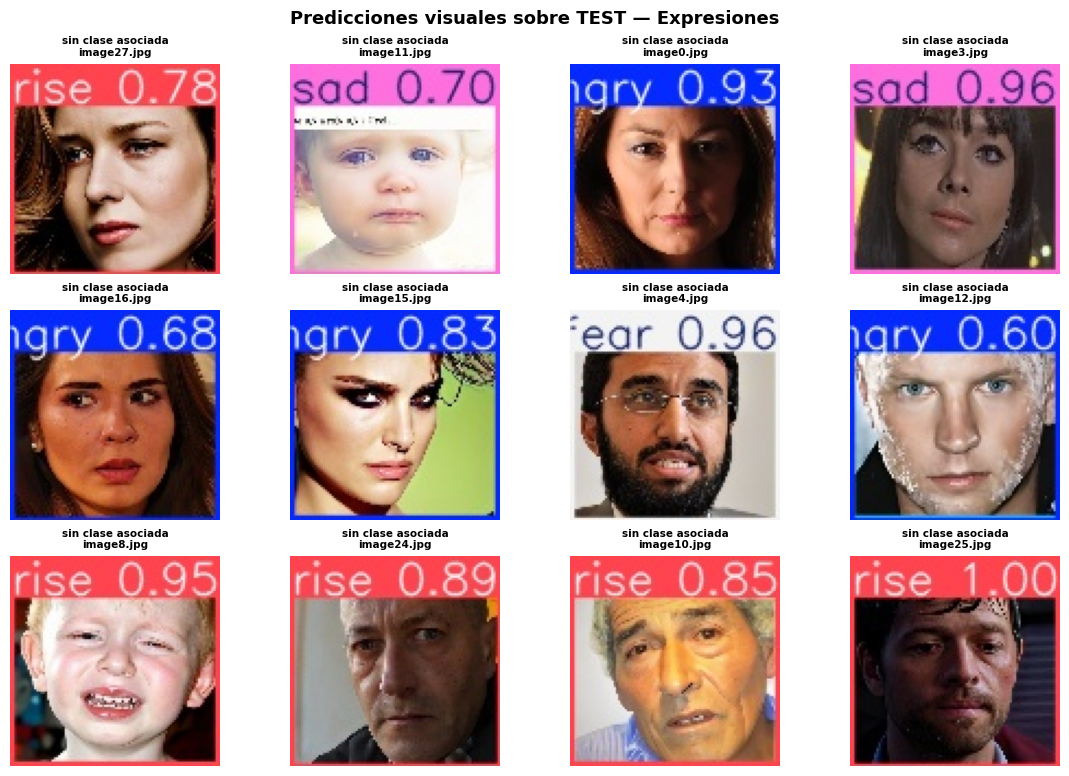


✅ Visualización completada sin modificar dataset ni fuentes.
Modo usado: fallback visual sin asociación de clase.

Carpetas revisadas:
 - /content/drive/MyDrive/TFM/predicciones_yolo_expresiones/test_visual_baseline_yolov8n


In [29]:
# ============================================================
# CELDA 9 – Mostrar predicciones visuales guardadas por clase
# Proyecto: Reconocimiento de expresiones con YOLOv8n
#
# Esta versión:
#   - NO modifica dataset.
#   - NO modifica predicciones.
#   - NO entrena.
#   - NO predice.
#   - Busca en todas las carpetas de predicciones de expresiones.
#   - Intenta mostrar al menos una imagen por clase real.
#   - Si no puede asociar labels, muestra predicciones disponibles sin fallar.
#   - Mejora la visualización con tamaño más compacto.
# ============================================================

from pathlib import Path
from collections import defaultdict
import random
import math
import yaml
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 1. Rutas explícitas del proyecto de EXPRESIONES
# ------------------------------------------------------------

MYDRIVE = Path("/content/drive/MyDrive")
TFM_DIR = MYDRIVE / "TFM"

DATASET_DIR = TFM_DIR / "EXPRESIONES" / "YOLO_EXPRESIONES_UNIFIED"
DATA_YAML = DATASET_DIR / "data.yaml"
TEST_LABEL_DIR = DATASET_DIR / "labels" / "test"

PRED_PROJECT = TFM_DIR / "predicciones_yolo_expresiones"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

CLASES_ESPERADAS = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

print("=" * 70)
print("🖼️ MOSTRAR PREDICCIONES VISUALES POR CLASE - EXPRESIONES")
print("=" * 70)

print("DATASET_DIR   :", DATASET_DIR)
print("Existe?       :", DATASET_DIR.exists())
print("DATA_YAML     :", DATA_YAML)
print("Existe?       :", DATA_YAML.exists())
print("TEST_LABEL_DIR:", TEST_LABEL_DIR)
print("Existe?       :", TEST_LABEL_DIR.exists())
print("PRED_PROJECT  :", PRED_PROJECT)
print("Existe?       :", PRED_PROJECT.exists())

if not DATA_YAML.exists():
    raise FileNotFoundError(f"No se encontró data.yaml:\n{DATA_YAML}")

if not TEST_LABEL_DIR.exists():
    raise FileNotFoundError(f"No se encontró labels/test:\n{TEST_LABEL_DIR}")

if not PRED_PROJECT.exists():
    raise FileNotFoundError(
        "No existe la carpeta de predicciones de expresiones.\n"
        f"Ruta revisada:\n{PRED_PROJECT}\n\n"
        "Primero ejecuta la celda de inferencia visual con predicciones guardadas."
    )

# ------------------------------------------------------------
# 2. Leer clases desde data.yaml
# ------------------------------------------------------------

def normalizar_names(names):
    if isinstance(names, list):
        return list(names)

    if isinstance(names, dict):
        return [names[k] for k in sorted(names, key=lambda x: int(x))]

    raise ValueError("No se pudo interpretar la sección names del data.yaml.")


with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = normalizar_names(data_yaml.get("names"))
NUM_CLASSES = len(CLASS_NAMES)

print("\n🎭 Clases detectadas:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

if CLASS_NAMES != CLASES_ESPERADAS:
    raise ValueError(
        "⚠️ Las clases detectadas no corresponden a expresiones.\n"
        f"Detectadas: {CLASS_NAMES}\n"
        f"Esperadas : {CLASES_ESPERADAS}"
    )

# ------------------------------------------------------------
# 3. Buscar carpetas de predicciones de expresiones
# ------------------------------------------------------------

PRED_PREFIXES = [
    "test_visual_baseline_yolov8n_expresiones",
    "test_visual_baseline_yolov8n"
]

candidatas = []

for carpeta in PRED_PROJECT.iterdir():
    if not carpeta.is_dir():
        continue

    nombre_lower = carpeta.name.lower()

    if any(carpeta.name.startswith(prefijo) for prefijo in PRED_PREFIXES):
        if (
            "caidas" not in nombre_lower
            and "baokhang" not in nombre_lower
            and "fall" not in nombre_lower
        ):
            candidatas.append(carpeta)

candidatas = sorted(
    candidatas,
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

print(f"\nCarpetas candidatas encontradas: {len(candidatas)}")

for i, p in enumerate(candidatas, start=1):
    print(f"{i}. {p.name}")

if len(candidatas) == 0:
    raise FileNotFoundError(
        "No se encontraron carpetas de predicciones visuales de expresiones.\n"
        f"Carpeta revisada:\n{PRED_PROJECT}"
    )

# ------------------------------------------------------------
# 4. Funciones auxiliares
# ------------------------------------------------------------

def imagen_legible(path_img):
    try:
        with Image.open(path_img) as img:
            img.verify()

        with Image.open(path_img) as img:
            img.load()

        return True

    except Exception:
        return False


def clase_dominante_desde_label(label_path):
    clases = []

    if not label_path.exists():
        return None

    try:
        with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) == 5:
                    cid = int(float(parts[0]))

                    if 0 <= cid < NUM_CLASSES:
                        clases.append(cid)

    except Exception:
        return None

    if not clases:
        return None

    return max(set(clases), key=clases.count)


def resolver_label_para_prediccion(img_path):
    """
    Intenta asociar una imagen de predicción con su label real de TEST.

    Caso ideal:
        predicción: AFFECTNET_-_image0003499.jpg
        label    : AFFECTNET_-_image0003499.txt
    """

    label_directo = TEST_LABEL_DIR / f"{img_path.stem}.txt"

    if label_directo.exists():
        return label_directo

    # Fallback por minúsculas, por si hay diferencias de mayúsculas/minúsculas
    stem_lower = img_path.stem.lower()

    for lbl in TEST_LABEL_DIR.glob("*.txt"):
        if lbl.stem.lower() == stem_lower:
            return lbl

    return None

# ------------------------------------------------------------
# 5. Recopilar predicciones de todas las carpetas candidatas
# ------------------------------------------------------------

todas_predicciones = []

for carpeta in candidatas:
    imgs = sorted([
        p for p in carpeta.iterdir()
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ])

    for img in imgs:
        todas_predicciones.append(img)

print(f"\nTotal de imágenes de predicción encontradas: {len(todas_predicciones):,}")

if len(todas_predicciones) == 0:
    print("\nContenido de la carpeta más reciente:")
    for p in sorted(candidatas[0].iterdir()):
        tipo = "📁" if p.is_dir() else "📄"
        print(f"{tipo} {p.name}")

    raise RuntimeError(
        "No se encontraron imágenes de predicción en las carpetas candidatas."
    )

# ------------------------------------------------------------
# 6. Asociar predicciones con clases reales
# ------------------------------------------------------------

por_clase = defaultdict(list)
predicciones_sin_label = []
predicciones_no_legibles = []
predicciones_mapeadas = []

# Evitar duplicados por nombre: nos quedamos con la versión más reciente
vistos = set()

for img_path in todas_predicciones:
    clave = img_path.name

    if clave in vistos:
        continue

    vistos.add(clave)

    if not imagen_legible(img_path):
        predicciones_no_legibles.append(img_path)
        continue

    label_path = resolver_label_para_prediccion(img_path)

    if label_path is None:
        predicciones_sin_label.append(img_path)
        continue

    cid = clase_dominante_desde_label(label_path)

    if cid is None:
        predicciones_sin_label.append(img_path)
        continue

    por_clase[cid].append(img_path)
    predicciones_mapeadas.append(img_path)

print("\n📋 Predicciones asociadas por clase real:")
for cid, cname in enumerate(CLASS_NAMES):
    print(f"  {cid} - {cname:<10}: {len(por_clase[cid]):,}")

print(f"\nPredicciones mapeadas con label real : {len(predicciones_mapeadas):,}")
print(f"Predicciones sin label asociado      : {len(predicciones_sin_label):,}")
print(f"Predicciones no legibles             : {len(predicciones_no_legibles):,}")

# ------------------------------------------------------------
# 7. Selección balanceada por clase
# ------------------------------------------------------------

random.seed(42)

N_TOTAL_MAX = 14   # máximo 2 por clase, visualización compacta
seleccionadas = []

# Primero, una por clase
for cid in range(NUM_CLASSES):
    disponibles = por_clase[cid]

    if len(disponibles) > 0:
        seleccionadas.append(random.choice(disponibles))

# Luego, completar con extras sin repetir
ya_usadas = {p.name for p in seleccionadas}
restantes = []

for cid in range(NUM_CLASSES):
    for p in por_clase[cid]:
        if p.name not in ya_usadas:
            restantes.append(p)

random.shuffle(restantes)

faltan = max(0, N_TOTAL_MAX - len(seleccionadas))
seleccionadas.extend(restantes[:faltan])

def obtener_clase_img(img_path):
    label_path = resolver_label_para_prediccion(img_path)

    if label_path is None:
        return None

    return clase_dominante_desde_label(label_path)

seleccionadas = sorted(
    seleccionadas,
    key=lambda p: obtener_clase_img(p) if obtener_clase_img(p) is not None else 999
)

# ------------------------------------------------------------
# 8. Fallback: si no se pudo mapear ninguna, mostrar disponibles
# ------------------------------------------------------------

modo_balanceado = True

if len(seleccionadas) == 0:
    modo_balanceado = False

    print("\n⚠️ No fue posible asociar las predicciones con labels/test.")
    print("Esto suele pasar si YOLO guardó las imágenes como image0, image1, etc.")
    print("Se mostrarán imágenes disponibles, pero sin garantizar cobertura por clase.")

    pred_legibles = [
        p for p in todas_predicciones
        if imagen_legible(p)
    ]

    if len(pred_legibles) == 0:
        raise RuntimeError(
            "No hay imágenes legibles para mostrar en las carpetas de predicciones."
        )

    seleccionadas = random.sample(
        pred_legibles,
        min(12, len(pred_legibles))
    )

# ------------------------------------------------------------
# 9. Reporte de cobertura
# ------------------------------------------------------------

print("\n✅ Imágenes seleccionadas para mostrar:")

clases_cubiertas = set()

for p in seleccionadas:
    cid = obtener_clase_img(p)

    if cid is not None:
        cname = CLASS_NAMES[cid]
        clases_cubiertas.add(cid)
    else:
        cname = "clase no asociada"

    print(f"  {cname:<18} → {p.name}")

if modo_balanceado:
    print("\n📌 Clases cubiertas en la visualización:")
    for cid in sorted(clases_cubiertas):
        print(f"  ✅ {CLASS_NAMES[cid]}")

    faltantes = [
        CLASS_NAMES[cid]
        for cid in range(NUM_CLASSES)
        if cid not in clases_cubiertas
    ]

    if faltantes:
        print("\n⚠️ Clases no cubiertas con las predicciones existentes:")
        for c in faltantes:
            print(f"  - {c}")

        print(
            "\nPara cubrirlas, la celda de inferencia visual debe generar "
            "predicciones balanceadas desde TEST."
        )

# ------------------------------------------------------------
# 10. Visualización compacta
# ------------------------------------------------------------

cols = 4
rows = math.ceil(len(seleccionadas) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(11.2, 2.55 * rows),
    constrained_layout=True
)

axes = np.array(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for i, img_path in enumerate(seleccionadas):
    cid = obtener_clase_img(img_path)

    if cid is not None:
        titulo_clase = CLASS_NAMES[cid]
    else:
        titulo_clase = "sin clase asociada"

    with Image.open(img_path) as img:
        img = img.convert("RGB")

    axes[i].imshow(img)
    axes[i].set_title(
        f"{titulo_clase}\n{img_path.name[:26]}",
        fontsize=7.5,
        fontweight="bold"
    )
    axes[i].axis("off")

fig.suptitle(
    "Predicciones visuales sobre TEST — Expresiones",
    fontsize=13,
    fontweight="bold"
)

plt.show()

print("\n✅ Visualización completada sin modificar dataset ni fuentes.")

if modo_balanceado:
    print("Modo usado: balanceado por clase real.")
else:
    print("Modo usado: fallback visual sin asociación de clase.")

print("\nCarpetas revisadas:")
for p in candidatas:
    print(" -", p)

In [30]:
# ============================================================
# CELDA 8A – Inferencia visual balanceada sobre imágenes TEST
# Proyecto: Reconocimiento de expresiones con YOLOv8n
#
# Esta celda:
#   - NO entrena.
#   - NO modifica el dataset original.
#   - NO mueve ni borra imágenes fuente.
#   - Selecciona imágenes TEST balanceadas por clase real.
#   - Genera predicciones visuales.
#   - Guarda un manifest para que la CELDA 9 sepa qué clase mostrar.
# ============================================================

from pathlib import Path
from collections import defaultdict
import random
import shutil
import yaml
import gc
import torch
import pandas as pd
from PIL import Image
from ultralytics import YOLO

# ------------------------------------------------------------
# 1. Rutas explícitas del proyecto de EXPRESIONES
# ------------------------------------------------------------

MYDRIVE = Path("/content/drive/MyDrive")
TFM_DIR = MYDRIVE / "TFM"

DATASET_DIR = TFM_DIR / "EXPRESIONES" / "YOLO_EXPRESIONES_UNIFIED"
DATA_YAML = DATASET_DIR / "data.yaml"

TEST_IMG_DIR = DATASET_DIR / "images" / "test"
TEST_LBL_DIR = DATASET_DIR / "labels" / "test"

PROJECT_DIR = TFM_DIR / "runs_yolo_expresiones"
RUN_NAME = "baseline_yolov8n_expresiones"
RUN_DIR = PROJECT_DIR / RUN_NAME

BEST_MODEL = RUN_DIR / "weights" / "best.pt"

PRED_PROJECT = TFM_DIR / "predicciones_yolo_expresiones"
PRED_NAME = "test_visual_balanceado_expresiones"

TMP_SAMPLE_DIR = Path("/content/tmp_muestras_test_balanceadas_expresiones")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

CLASES_ESPERADAS = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

print("=" * 70)
print("🎭 INFERENCIA VISUAL BALANCEADA - EXPRESIONES")
print("=" * 70)

print("DATASET_DIR :", DATASET_DIR)
print("Existe?     :", DATASET_DIR.exists())
print("DATA_YAML   :", DATA_YAML)
print("Existe?     :", DATA_YAML.exists())
print("TEST_IMG_DIR:", TEST_IMG_DIR)
print("Existe?     :", TEST_IMG_DIR.exists())
print("TEST_LBL_DIR:", TEST_LBL_DIR)
print("Existe?     :", TEST_LBL_DIR.exists())
print("BEST_MODEL  :", BEST_MODEL)
print("Existe?     :", BEST_MODEL.exists())

if not DATA_YAML.exists():
    raise FileNotFoundError(f"No se encontró data.yaml:\n{DATA_YAML}")

if not TEST_IMG_DIR.exists():
    raise FileNotFoundError(f"No se encontró images/test:\n{TEST_IMG_DIR}")

if not TEST_LBL_DIR.exists():
    raise FileNotFoundError(f"No se encontró labels/test:\n{TEST_LBL_DIR}")

if not BEST_MODEL.exists():
    raise FileNotFoundError(f"No se encontró best.pt:\n{BEST_MODEL}")

# ------------------------------------------------------------
# 2. Leer clases desde data.yaml
# ------------------------------------------------------------

def normalizar_names(names):
    if isinstance(names, list):
        return list(names)

    if isinstance(names, dict):
        return [names[k] for k in sorted(names, key=lambda x: int(x))]

    raise ValueError("No se pudo interpretar la sección names del data.yaml.")


with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = normalizar_names(data_yaml.get("names"))
NUM_CLASSES = len(CLASS_NAMES)

print("\nClases detectadas:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

if CLASS_NAMES != CLASES_ESPERADAS:
    raise ValueError(
        "Las clases detectadas no corresponden al proyecto de expresiones.\n"
        f"Detectadas: {CLASS_NAMES}\n"
        f"Esperadas : {CLASES_ESPERADAS}"
    )

# ------------------------------------------------------------
# 3. Funciones auxiliares
# ------------------------------------------------------------

def imagen_es_valida(path_img):
    try:
        with Image.open(path_img) as img:
            img.verify()

        with Image.open(path_img) as img:
            img.load()

        return True

    except Exception:
        return False


def clase_dominante_desde_label(label_path):
    clases = []

    if not label_path.exists():
        return None

    try:
        with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) == 5:
                    cid = int(float(parts[0]))

                    if 0 <= cid < NUM_CLASSES:
                        clases.append(cid)

    except Exception:
        return None

    if not clases:
        return None

    return max(set(clases), key=clases.count)

# ------------------------------------------------------------
# 4. Agrupar imágenes TEST válidas por clase real
# ------------------------------------------------------------

imgs_test = sorted([
    p for p in TEST_IMG_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMG_EXTS
])

print(f"\nImágenes TEST encontradas: {len(imgs_test):,}")

por_clase = defaultdict(list)
descartadas = []

for img_path in imgs_test:
    lbl_path = TEST_LBL_DIR / f"{img_path.stem}.txt"

    clase_id = clase_dominante_desde_label(lbl_path)

    if clase_id is None:
        descartadas.append((img_path.name, "sin_label_valido"))
        continue

    if not imagen_es_valida(img_path):
        descartadas.append((img_path.name, "imagen_no_legible"))
        continue

    por_clase[clase_id].append(img_path)

print("\nDisponibilidad por clase real en TEST:")
for cid, cname in enumerate(CLASS_NAMES):
    print(f"  {cid} - {cname:<10}: {len(por_clase[cid]):,}")

if descartadas:
    print(f"\nImágenes descartadas para esta muestra visual: {len(descartadas):,}")
    print("Primeros ejemplos:")
    for nombre, motivo in descartadas[:10]:
        print(f" - {nombre}: {motivo}")

# ------------------------------------------------------------
# 5. Selección balanceada
# ------------------------------------------------------------

random.seed(42)

N_POR_CLASE = 2

seleccionadas = []

for cid in range(NUM_CLASSES):
    disponibles = por_clase[cid]

    if len(disponibles) == 0:
        print(f"⚠️ No hay imágenes válidas disponibles para la clase: {CLASS_NAMES[cid]}")
        continue

    n = min(N_POR_CLASE, len(disponibles))
    elegidas = random.sample(disponibles, n)

    for img_path in elegidas:
        seleccionadas.append({
            "clase_id": cid,
            "clase_real": CLASS_NAMES[cid],
            "imagen_original": img_path.name,
            "ruta_imagen_original": str(img_path),
            "label_original": f"{img_path.stem}.txt",
            "ruta_label_original": str(TEST_LBL_DIR / f"{img_path.stem}.txt")
        })

df_manifest = pd.DataFrame(seleccionadas)

if len(df_manifest) == 0:
    raise RuntimeError("No se pudo seleccionar ninguna imagen válida para inferencia visual.")

print("\nImágenes seleccionadas para inferencia:")
display(df_manifest[["clase_id", "clase_real", "imagen_original"]])

# ------------------------------------------------------------
# 6. Crear carpeta temporal con nombres originales
# ------------------------------------------------------------

if TMP_SAMPLE_DIR.exists():
    shutil.rmtree(TMP_SAMPLE_DIR)

TMP_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

for _, row in df_manifest.iterrows():
    src = Path(row["ruta_imagen_original"])
    dst = TMP_SAMPLE_DIR / src.name
    shutil.copy2(src, dst)

print("\nMuestras copiadas temporalmente en:")
print(TMP_SAMPLE_DIR)

# ------------------------------------------------------------
# 7. Ejecutar inferencia visual
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass

device = 0 if torch.cuda.is_available() else "cpu"

print("\nDispositivo usado:", device)

model_best = YOLO(str(BEST_MODEL))

print("\n" + "=" * 70)
print("🚀 EJECUTANDO PREDICCIÓN VISUAL BALANCEADA")
print("=" * 70)

pred_results = model_best.predict(
    source=str(TMP_SAMPLE_DIR),
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True,
    project=str(PRED_PROJECT),
    name=PRED_NAME,
    exist_ok=True,
    device=device,
    batch=1,
    verbose=True
)

OUT_DIR = PRED_PROJECT / PRED_NAME

print("\nCarpeta de salida:")
print(OUT_DIR)

# ------------------------------------------------------------
# 8. Completar manifest con ruta de imagen predicha
# ------------------------------------------------------------

pred_imgs = sorted([
    p for p in OUT_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMG_EXTS
])

pred_por_stem = {p.stem: p for p in pred_imgs}

rutas_predichas = []

for _, row in df_manifest.iterrows():
    stem = Path(row["imagen_original"]).stem
    pred_path = pred_por_stem.get(stem)

    if pred_path is not None:
        rutas_predichas.append(str(pred_path))
    else:
        rutas_predichas.append("")

df_manifest["ruta_imagen_predicha"] = rutas_predichas
df_manifest["imagen_predicha"] = [
    Path(p).name if p else ""
    for p in df_manifest["ruta_imagen_predicha"]
]

MANIFEST_CSV = OUT_DIR / "manifest_predicciones_balanceadas_expresiones.csv"
df_manifest.to_csv(MANIFEST_CSV, index=False)

print("\n✅ Manifest guardado en:")
print(MANIFEST_CSV)

print("\nResumen de manifest:")
display(df_manifest[["clase_real", "imagen_original", "imagen_predicha"]])

sin_pred = df_manifest[df_manifest["ruta_imagen_predicha"] == ""]

if len(sin_pred) > 0:
    print("\n⚠️ Algunas imágenes no pudieron asociarse con archivo predicho:")
    display(sin_pred[["clase_real", "imagen_original"]])
else:
    print("\n✅ Todas las imágenes seleccionadas tienen predicción asociada.")

print("\n✅ CELDA 8 completada sin modificar el dataset original.")

🎭 INFERENCIA VISUAL BALANCEADA - EXPRESIONES
DATASET_DIR : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
Existe?     : True
DATA_YAML   : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/data.yaml
Existe?     : True
TEST_IMG_DIR: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/images/test
Existe?     : True
TEST_LBL_DIR: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/labels/test
Existe?     : True
BEST_MODEL  : /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones/weights/best.pt
Existe?     : True

Clases detectadas:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise

Imágenes TEST encontradas: 3,586

Disponibilidad por clase real en TEST:
  0 - angry     : 492
  1 - disgust   : 104
  2 - fear      : 173
  3 - happy     : 204
  4 - neutral   : 32
  5 - sad       : 137
  6 - surprise  : 367

Imágenes descartadas para esta muestra visual: 2,077
Primeros ejemplos:
 - AF

,clase_id,clase_real,imagen_original
0,0,angry,AFFECTNET_image0023191.jpg
1,0,angry,AFFECTNET_image0006699.jpg
2,1,disgust,AFFECTNET_image0003828.jpg
3,1,disgust,AFFECTNET_image0027852.jpg
4,2,fear,AFFECTNET_image0018099.jpg
5,2,fear,AFFECTNET_image0016628.jpg
6,3,happy,AFFECTNET_image0014623.jpg
7,3,happy,AFFECTNET_image0009136.jpg
8,4,neutral,AFFECTNET_image0012700.jpg
9,4,neutral,AFFECTNET_image0012293.jpg



Muestras copiadas temporalmente en:
/content/tmp_muestras_test_balanceadas_expresiones

Dispositivo usado: 0

🚀 EJECUTANDO PREDICCIÓN VISUAL BALANCEADA

image 1/14 /content/tmp_muestras_test_balanceadas_expresiones/AFFECTNET_image0002436.jpg: 640x640 1 surprise, 8.3ms
image 2/14 /content/tmp_muestras_test_balanceadas_expresiones/AFFECTNET_image0003828.jpg: 640x640 1 disgust, 1 sad, 8.0ms
image 3/14 /content/tmp_muestras_test_balanceadas_expresiones/AFFECTNET_image0003884.jpg: 640x640 1 sad, 7.2ms
image 4/14 /content/tmp_muestras_test_balanceadas_expresiones/AFFECTNET_image0006515.jpg: 640x640 1 surprise, 7.2ms
image 5/14 /content/tmp_muestras_test_balanceadas_expresiones/AFFECTNET_image0006699.jpg: 640x640 1 disgust, 7.2ms
image 6/14 /content/tmp_muestras_test_balanceadas_expresiones/AFFECTNET_image0009136.jpg: 640x640 1 happy, 7.2ms
image 7/14 /content/tmp_muestras_test_balanceadas_expresiones/AFFECTNET_image0012293.jpg: 640x640 1 fear, 7.2ms
image 8/14 /content/tmp_muestras_test_bal

,clase_real,imagen_original,imagen_predicha
0,angry,AFFECTNET_image0023191.jpg,AFFECTNET_image0023191.jpg
1,angry,AFFECTNET_image0006699.jpg,AFFECTNET_image0006699.jpg
2,disgust,AFFECTNET_image0003828.jpg,AFFECTNET_image0003828.jpg
3,disgust,AFFECTNET_image0027852.jpg,AFFECTNET_image0027852.jpg
4,fear,AFFECTNET_image0018099.jpg,AFFECTNET_image0018099.jpg
5,fear,AFFECTNET_image0016628.jpg,AFFECTNET_image0016628.jpg
6,happy,AFFECTNET_image0014623.jpg,AFFECTNET_image0014623.jpg
7,happy,AFFECTNET_image0009136.jpg,AFFECTNET_image0009136.jpg
8,neutral,AFFECTNET_image0012700.jpg,AFFECTNET_image0012700.jpg
9,neutral,AFFECTNET_image0012293.jpg,AFFECTNET_image0012293.jpg



✅ Todas las imágenes seleccionadas tienen predicción asociada.

✅ CELDA 8 completada sin modificar el dataset original.



🖼️ MUESTRA VISUAL BALANCEADA GENERADA
Imágenes válidas para mostrar: 14

Cobertura por clase:


,clase_real,imagenes
0,angry,2
1,disgust,2
2,fear,2
3,happy,2
4,neutral,2
5,sad,2
6,surprise,2


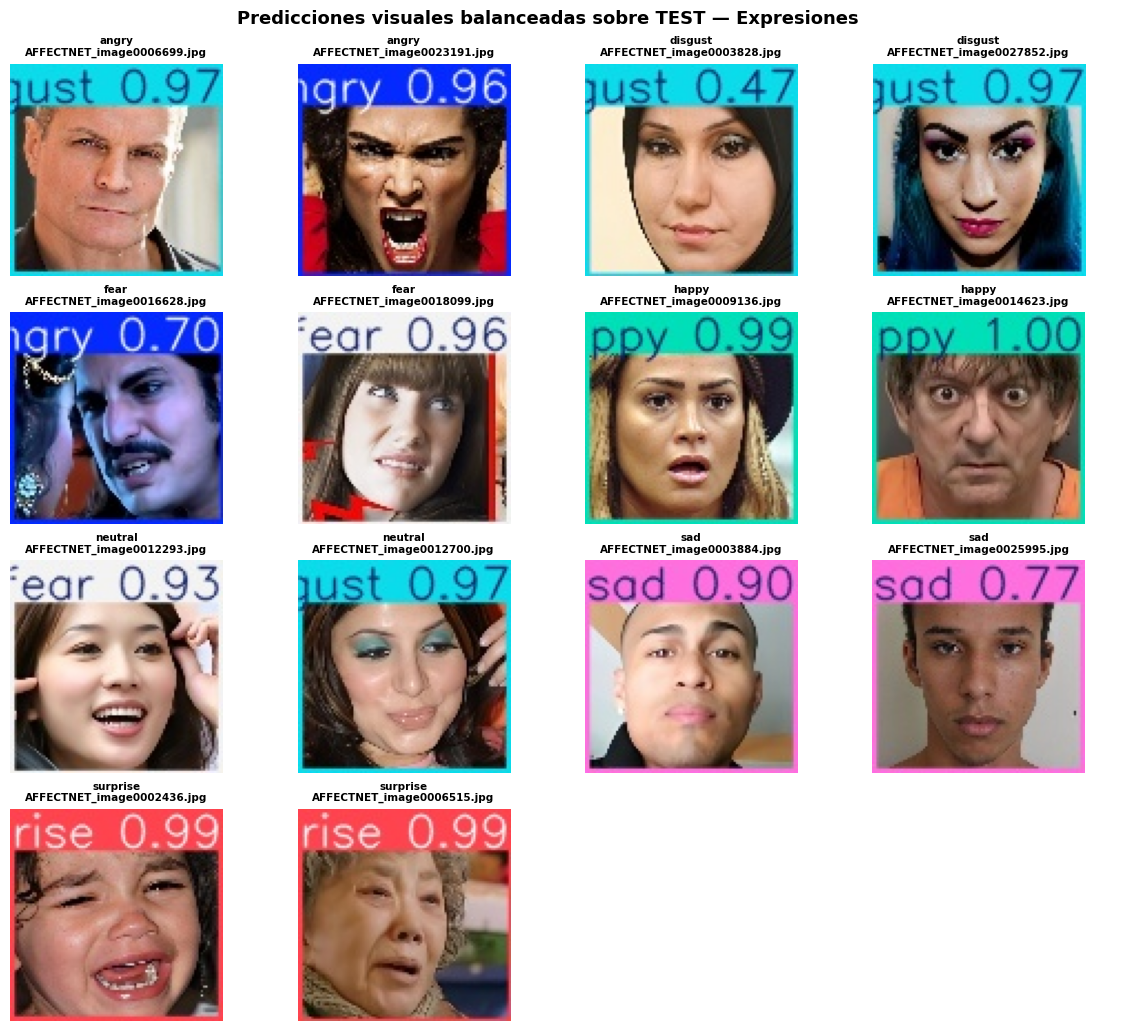


✅ Muestra visual mostrada en pantalla.
✅ Figura resumen guardada en:
/content/drive/MyDrive/TFM/predicciones_yolo_expresiones/test_visual_balanceado_expresiones/muestra_predicciones_balanceadas_expresiones.png


In [31]:
# ------------------------------------------------------------
# 9. Mostrar muestra visual balanceada generada
#
# NO modifica dataset.
# NO modifica imágenes fuente.
# Solo lee las predicciones guardadas y las muestra en pantalla.
# ------------------------------------------------------------

import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("\n" + "=" * 70)
print("🖼️ MUESTRA VISUAL BALANCEADA GENERADA")
print("=" * 70)

# Usar el manifest recién creado
if not MANIFEST_CSV.exists():
    raise FileNotFoundError(
        f"No se encontró el manifest:\n{MANIFEST_CSV}"
    )

df_plot = pd.read_csv(MANIFEST_CSV)

# Quedarnos solo con predicciones asociadas correctamente
df_plot = df_plot[
    df_plot["ruta_imagen_predicha"].notna()
    & (df_plot["ruta_imagen_predicha"].astype(str).str.len() > 0)
].copy()

# Validar existencia de las imágenes predichas
filas_validas = []

for _, row in df_plot.iterrows():
    pred_path = Path(row["ruta_imagen_predicha"])

    if not pred_path.exists():
        continue

    try:
        with Image.open(pred_path) as img:
            img.verify()

        filas_validas.append(row)

    except Exception:
        pass

df_plot = pd.DataFrame(filas_validas)

if len(df_plot) == 0:
    raise RuntimeError(
        "No hay imágenes predichas válidas para mostrar. "
        "Revisa la carpeta de salida de predicciones."
    )

# Ordenar por clase para que la visualización quede clara
df_plot = df_plot.sort_values(
    ["clase_id", "imagen_original"]
).reset_index(drop=True)

print("Imágenes válidas para mostrar:", len(df_plot))

print("\nCobertura por clase:")
display(
    df_plot.groupby("clase_real")
    .size()
    .reset_index(name="imagenes")
)

# ------------------------------------------------------------
# Configuración visual compacta
# ------------------------------------------------------------

cols = 4
rows = math.ceil(len(df_plot) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(11.5, 2.55 * rows),
    constrained_layout=True
)

axes = np.array(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for i, (_, row) in enumerate(df_plot.iterrows()):
    img_path = Path(row["ruta_imagen_predicha"])

    with Image.open(img_path) as img:
        img = img.convert("RGB")

    axes[i].imshow(img)
    axes[i].set_title(
        f"{row['clase_real']}\n{row['imagen_original'][:28]}",
        fontsize=7.5,
        fontweight="bold"
    )
    axes[i].axis("off")

fig.suptitle(
    "Predicciones visuales balanceadas sobre TEST — Expresiones",
    fontsize=13,
    fontweight="bold"
)

# Guardar también la figura resumen en la carpeta de predicciones
OUT_FIG = OUT_DIR / "muestra_predicciones_balanceadas_expresiones.png"

plt.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.25
)

plt.show()

print("\n✅ Muestra visual mostrada en pantalla.")
print("✅ Figura resumen guardada en:")
print(OUT_FIG)

Se exploró el reconocimiento de expresiones como posible componente complementario, pero se descartó porque no aportaba de forma directa al objetivo central del sistema, que es la detección de caídas, y porque los resultados visuales mostraron baja coherencia práctica frente a las clases esperadas.



Durante el desarrollo experimental se consideró inicialmente la posibilidad de incorporar un componente complementario de reconocimiento de expresiones faciales. Esta alternativa se evaluó como una línea exploratoria orientada a analizar si las expresiones podían aportar información adicional al contexto de una posible caída. Sin embargo, tras revisar los resultados obtenidos, se decidió no incluir este componente dentro del modelo final.

La decisión se fundamentó en criterios de pertinencia metodológica, calidad de datos y coherencia práctica de los resultados. En primer lugar, el objetivo central del proyecto es la detección de caídas, por lo que la variable principal de análisis corresponde a la postura corporal, la posición de la persona y la escena visual asociada al evento. Las expresiones faciales no constituyen una condición necesaria ni suficiente para determinar la ocurrencia de una caída, especialmente en escenarios donde el rostro no es visible, se encuentra parcialmente ocluido o la imagen no permite identificar rasgos faciales con claridad.

En segundo lugar, la evaluación visual de las predicciones del modelo de expresiones mostró inconsistencias entre las clases reales y las clases inferidas. Aunque el modelo generó salidas para las distintas categorías de expresión, algunas predicciones no resultaron coherentes con la apariencia visual de las imágenes evaluadas. Esto evidenció que la incorporación de dicho componente podía introducir ruido interpretativo y afectar la claridad del sistema propuesto.

Adicionalmente, durante la revisión técnica del conjunto de datos de expresiones se identificaron archivos de imagen no legibles o corruptos, lo cual exige una depuración adicional del dataset antes de considerar su uso en una solución integrada. Dado que esta línea no era indispensable para responder al problema de investigación, se optó por delimitar el alcance del sistema al componente de detección de caídas mediante YOLOv8n.

En consecuencia, el modelo final del proyecto se concentra exclusivamente en la detección de caídas, considerando las clases “fall” y “non_fall”. Esta delimitación permite mantener la coherencia entre el objetivo de investigación, el conjunto de datos utilizado, las métricas de evaluación y la interpretación de los resultados. El reconocimiento de expresiones se conserva únicamente como una exploración preliminar no incorporada al sistema final.


### 🔎 Sección 10 – Comparación predicción vs etiqueta real

Para expresiones cada imagen tiene una expresión dominante, así que se compara la
**clase de mayor confianza** predicha contra la clase real (la más frecuente en el
label). Se obtiene un DataFrame de aciertos/errores y la exactitud sobre la muestra.

In [9]:
# ============================================================
# CELDA 10 – Comparar predicción vs etiqueta real en muestras
# ============================================================
GT_LABEL_DIR   = YOLO_DATASET / "labels" / "test"
PRED_DIR       = TFM_DIR / "predicciones_yolo_expresiones" / "test_visual_baseline_yolov8n"
PRED_LABEL_DIR = PRED_DIR / "labels"

print("=" * 70)
print("🔎 COMPARACIÓN PREDICCIÓN VS ETIQUETA REAL")
print("=" * 70)
print(f"📁 GT labels   : {GT_LABEL_DIR}")
print(f"📁 Pred labels : {PRED_LABEL_DIR}")

def leer_gt_label(path):
    if not path.exists() or path.stat().st_size == 0:
        return None
    clases = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                try:
                    clases.append(int(float(parts[0])))
                except Exception:
                    pass
    return max(set(clases), key=clases.count) if clases else None

def leer_pred_label(path):
    if not path.exists() or path.stat().st_size == 0:
        return None, None
    preds = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 6:
                try:
                    preds.append((int(float(parts[0])), float(parts[5])))
                except Exception:
                    pass
    if not preds:
        return None, None
    pred = max(preds, key=lambda x: x[1])
    return pred[0], pred[1]

def nombre_clase(cid):
    return CLASS_NAMES[cid] if cid is not None and 0 <= cid < len(CLASS_NAMES) else None

filas = []
if PRED_LABEL_DIR.exists():
    pred_files = sorted(p for p in PRED_LABEL_DIR.iterdir() if p.suffix.lower() == ".txt")
    for pred_path in pred_files:
        stem = pred_path.stem
        gt_cls = leer_gt_label(GT_LABEL_DIR / f"{stem}.txt")
        pred_cls, conf = leer_pred_label(pred_path)
        filas.append({
            "imagen": stem,
            "gt_class": nombre_clase(gt_cls) or "SIN_GT",
            "pred_class": nombre_clase(pred_cls) or "SIN_PRED",
            "confidence": conf,
            "correcto": (gt_cls is not None and gt_cls == pred_cls),
        })

df_comparacion = pd.DataFrame(filas)
print("\n📋 Comparación:")
display(df_comparacion)

if len(df_comparacion) > 0:
    acc = df_comparacion["correcto"].mean() * 100
    print(f"\n✅ Exactitud en estas muestras: {acc:.2f}%")
    errores = df_comparacion[~df_comparacion["correcto"]]
    if len(errores) > 0:
        print("\n⚠️ Errores encontrados:")
        display(errores)
    else:
        print("\n✅ Sin errores en las predicciones guardadas de la muestra.")


🔎 COMPARACIÓN PREDICCIÓN VS ETIQUETA REAL
📁 GT labels   : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15_CLEAN/labels/test
📁 Pred labels : /content/drive/MyDrive/TFM/predicciones_yolo_expresiones/test_visual_baseline_yolov8n/labels

📋 Comparación:


,imagen,gt_class,pred_class,confidence,correcto
0,image0,SIN_GT,fall,0.930467,False
1,image1,SIN_GT,non_fall,0.938242,False
2,image10,SIN_GT,SIN_PRED,0.853079,False
3,image11,SIN_GT,SIN_PRED,0.696476,False
4,image12,SIN_GT,fall,0.595600,False
5,image13,SIN_GT,SIN_PRED,0.903501,False
6,image14,SIN_GT,SIN_PRED,0.473586,False
7,image15,SIN_GT,fall,0.834478,False
8,image16,SIN_GT,fall,0.680611,False
9,image17,SIN_GT,SIN_PRED,0.889551,False



✅ Exactitud en estas muestras: 0.00%

⚠️ Errores encontrados:


,imagen,gt_class,pred_class,confidence,correcto
0,image0,SIN_GT,fall,0.930467,False
1,image1,SIN_GT,non_fall,0.938242,False
2,image10,SIN_GT,SIN_PRED,0.853079,False
3,image11,SIN_GT,SIN_PRED,0.696476,False
4,image12,SIN_GT,fall,0.595600,False
5,image13,SIN_GT,SIN_PRED,0.903501,False
6,image14,SIN_GT,SIN_PRED,0.473586,False
7,image15,SIN_GT,fall,0.834478,False
8,image16,SIN_GT,fall,0.680611,False
9,image17,SIN_GT,SIN_PRED,0.889551,False


## 🗂️ Sección 11 – Copiar figuras oficiales de YOLO para documentación

In [10]:
# ============================================================
# CELDA 11 – Copiar figuras oficiales de YOLO (matriz, curvas, batches)
# ============================================================
import shutil

TEST_EVAL_DIR = PROJECT_DIR / f"{RUN_NAME}_test_eval"
FIG_DIR = TFM_DIR / "figuras_resultados_yolo_expresiones"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Según la versión de Ultralytics, las curvas pueden venir con prefijo "Box".
candidatos = [
    "confusion_matrix.png", "confusion_matrix_normalized.png",
    "PR_curve.png", "F1_curve.png", "P_curve.png", "R_curve.png",
    "BoxPR_curve.png", "BoxF1_curve.png", "BoxP_curve.png", "BoxR_curve.png",
    "val_batch0_labels.jpg", "val_batch0_pred.jpg",
    "val_batch1_labels.jpg", "val_batch1_pred.jpg",
    "val_batch2_labels.jpg", "val_batch2_pred.jpg",
    "metricas_test_resumen.csv", "metricas_test_resumen.txt",
]

print("=" * 70)
print("📁 COPIANDO FIGURAS OFICIALES DE TEST")
print("=" * 70)
print(f"Origen : {TEST_EVAL_DIR}")
print(f"Destino: {FIG_DIR}")

copiados, no_encontrados = [], []
for nombre in candidatos:
    src = TEST_EVAL_DIR / nombre
    if src.exists():
        # las figuras llevan prefijo test_ ; los csv/txt se copian tal cual
        destino = nombre if nombre.endswith((".csv", ".txt")) else f"test_{nombre}"
        dst = FIG_DIR / destino
        shutil.copy2(src, dst)
        copiados.append(dst.name)
        print(f"✅ Copiado: {dst.name}")
    else:
        no_encontrados.append(nombre)

print(f"\n✅ Copiados: {len(copiados)} | ⚠️ No encontrados: {len(no_encontrados)}")
print(f"📁 Figuras disponibles en: {FIG_DIR}")


📁 COPIANDO FIGURAS OFICIALES DE TEST
Origen : /content/drive/MyDrive/TFM/runs_yolo_caidas/baseline_yolov8n_clean_70_15_15_test_eval
Destino: /content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones
✅ Copiado: test_confusion_matrix.png
✅ Copiado: test_confusion_matrix_normalized.png
✅ Copiado: test_BoxPR_curve.png
✅ Copiado: test_BoxF1_curve.png
✅ Copiado: test_BoxP_curve.png
✅ Copiado: test_BoxR_curve.png
✅ Copiado: test_val_batch0_labels.jpg
✅ Copiado: test_val_batch0_pred.jpg
✅ Copiado: test_val_batch1_labels.jpg
✅ Copiado: test_val_batch1_pred.jpg
✅ Copiado: test_val_batch2_labels.jpg
✅ Copiado: test_val_batch2_pred.jpg
✅ Copiado: metricas_test_resumen.csv
✅ Copiado: metricas_test_resumen.txt

✅ Copiados: 14 | ⚠️ No encontrados: 4
📁 Figuras disponibles en: /content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones


## 📈 Sección 12 – Gráficas de métricas `TEST` por clase

📊 GRÁFICAS DE MÉTRICAS TEST - EXPRESIONES
PROJECT_DIR_EXP : /content/drive/MyDrive/TFM/runs_yolo_expresiones
TEST_EVAL_DIR   : /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones_test_eval
CSV_METRICAS    : /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones_test_eval/metricas_test_resumen.csv
Existe CSV?     : True
FIG_DIR_EXP     : /content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones

✅ Métricas cargadas desde CSV de EXPRESIONES.

📋 Tabla cargada:


,clase,precision,recall,mAP50,mAP50_95
0,Global (all),0.757126,0.766381,0.812468,0.812468
1,angry,0.826985,0.853659,0.907375,0.907375
2,disgust,0.731297,0.798077,0.872515,0.872515
3,fear,0.611354,0.682081,0.722396,0.722396
4,happy,0.792383,0.852941,0.897334,0.897334
5,neutral,0.952378,0.624962,0.730871,0.730871
6,sad,0.649422,0.743682,0.697167,0.697167
7,surprise,0.736061,0.809264,0.859616,0.859616



📋 Tabla validada y ordenada:


,clase,precision,recall,mAP50,mAP50_95
0,Global (all),0.7571,0.7664,0.8125,0.8125
1,angry,0.8270,0.8537,0.9074,0.9074
2,disgust,0.7313,0.7981,0.8725,0.8725
3,fear,0.6114,0.6821,0.7224,0.7224
4,happy,0.7924,0.8529,0.8973,0.8973
5,neutral,0.9524,0.6250,0.7309,0.7309
6,sad,0.6494,0.7437,0.6972,0.6972
7,surprise,0.7361,0.8093,0.8596,0.8596


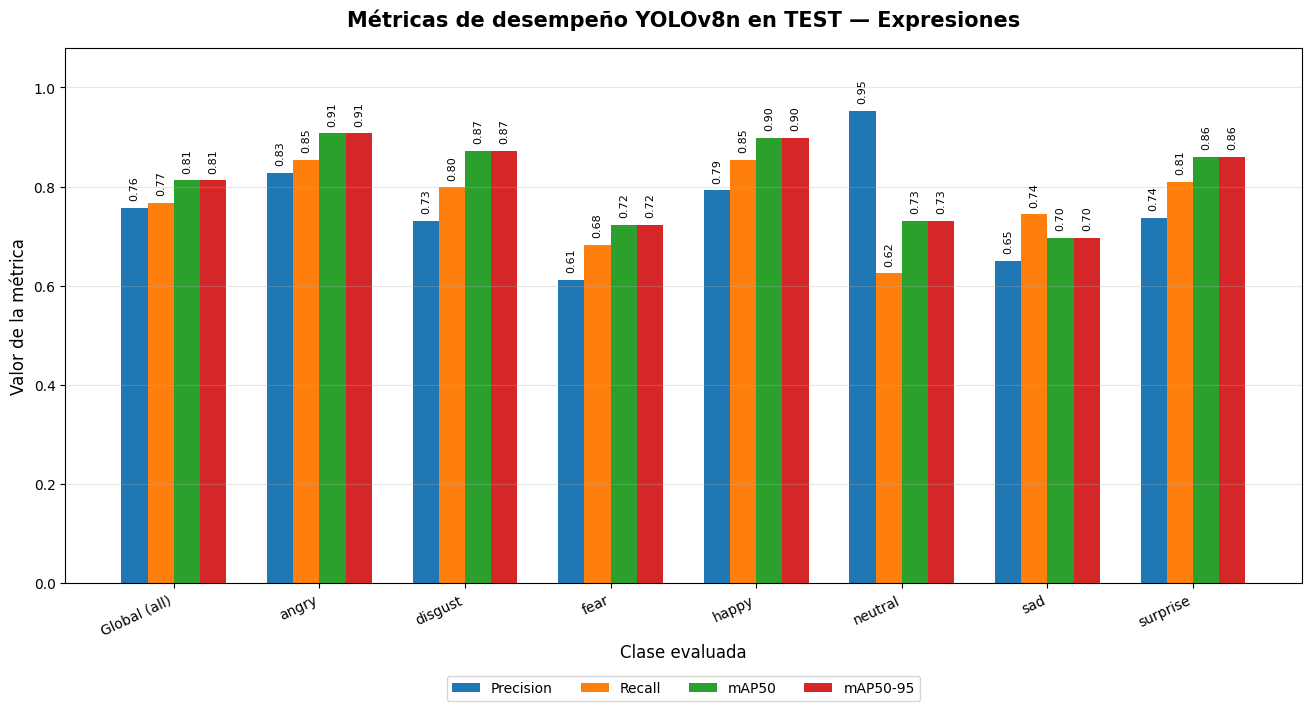

✅ Barras guardadas en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_metricas_test_barras_agrupadas_expresiones.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_metricas_test_barras_agrupadas_expresiones.pdf


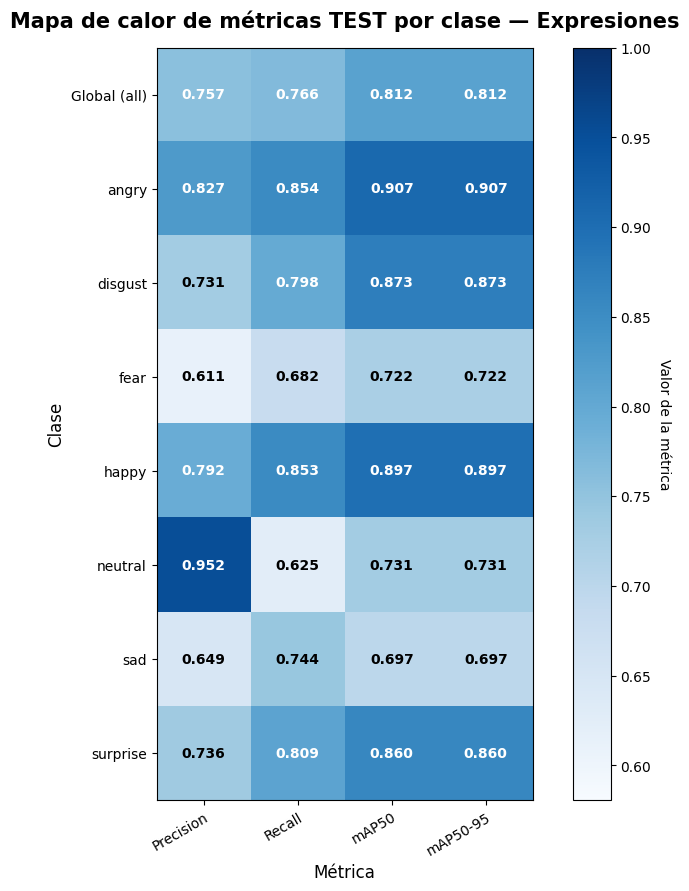

✅ Mapa de calor guardado en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_metricas_test_mapa_calor_expresiones.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_metricas_test_mapa_calor_expresiones.pdf


In [20]:
# ============================================================
# CELDA 12 – Gráficas de métricas TEST por clase
# Proyecto: Reconocimiento de expresiones con YOLOv8n
#
# Genera:
#   1. Gráfica de barras agrupadas
#   2. Mapa de calor de métricas TEST por clase
#
# Seguridad:
#   - NO usa df_metricas_test de memoria.
#   - NO usa PROJECT_DIR ni RUN_NAME previos.
#   - Lee únicamente el CSV del proyecto de EXPRESIONES.
#   - Valida que NO aparezcan clases de caídas: fall / non_fall.
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Rutas correctas del proyecto de EXPRESIONES
# ------------------------------------------------------------

MYDRIVE = Path("/content/drive/MyDrive")
TFM_DIR = MYDRIVE / "TFM"

PROJECT_DIR_EXP = TFM_DIR / "runs_yolo_expresiones"
RUN_NAME_EXP = "baseline_yolov8n_expresiones"

TEST_EVAL_DIR_EXP = PROJECT_DIR_EXP / f"{RUN_NAME_EXP}_test_eval"

FIG_DIR_EXP = TFM_DIR / "figuras_resultados_yolo_expresiones"
FIG_DIR_EXP.mkdir(parents=True, exist_ok=True)

CSV_METRICAS_EXP = TEST_EVAL_DIR_EXP / "metricas_test_resumen.csv"

CLASES_EXPRESIONES = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

print("=" * 70)
print("📊 GRÁFICAS DE MÉTRICAS TEST - EXPRESIONES")
print("=" * 70)

print("PROJECT_DIR_EXP :", PROJECT_DIR_EXP)
print("TEST_EVAL_DIR   :", TEST_EVAL_DIR_EXP)
print("CSV_METRICAS    :", CSV_METRICAS_EXP)
print("Existe CSV?     :", CSV_METRICAS_EXP.exists())
print("FIG_DIR_EXP     :", FIG_DIR_EXP)

# ------------------------------------------------------------
# 2. Cargar métricas TEST de expresiones
# ------------------------------------------------------------

if CSV_METRICAS_EXP.exists():
    df_m = pd.read_csv(CSV_METRICAS_EXP)
    print("\n✅ Métricas cargadas desde CSV de EXPRESIONES.")
else:
    raise FileNotFoundError(
        "No se encontró el CSV de métricas TEST de expresiones.\n"
        f"Ruta esperada:\n{CSV_METRICAS_EXP}\n\n"
        "Debes ejecutar primero la celda que guarda metricas_test_resumen.csv "
        "para el proyecto de expresiones."
    )

print("\n📋 Tabla cargada:")
display(df_m)

# ------------------------------------------------------------
# 3. Validaciones para evitar mezclar con CAÍDAS
# ------------------------------------------------------------

if "clase" not in df_m.columns:
    raise ValueError("El CSV no contiene la columna 'clase'.")

clases_detectadas = df_m["clase"].astype(str).tolist()
clases_detectadas_lower = [c.lower() for c in clases_detectadas]

# Si aparece fall/non_fall, el CSV NO es de expresiones
if "fall" in clases_detectadas_lower or "non_fall" in clases_detectadas_lower:
    raise ValueError(
        "⚠️ El CSV cargado contiene clases de CAÍDAS: fall / non_fall.\n"
        "Eso significa que estás leyendo métricas del proyecto equivocado.\n"
        f"CSV usado:\n{CSV_METRICAS_EXP}"
    )

# Verificar que aparezcan las clases de expresiones
faltantes = [c for c in CLASES_EXPRESIONES if c not in clases_detectadas_lower]

if len(faltantes) > 0:
    print("\n⚠️ Advertencia: no se encontraron algunas clases esperadas:")
    print(faltantes)

# ------------------------------------------------------------
# 4. Normalizar nombres de columnas de métricas
# ------------------------------------------------------------

# Algunas celdas pueden guardar mAP50_95 o mAP50-95.
# Aquí unificamos el nombre.
if "mAP50-95" in df_m.columns and "mAP50_95" not in df_m.columns:
    df_m = df_m.rename(columns={"mAP50-95": "mAP50_95"})

metricas = ["precision", "recall", "mAP50", "mAP50_95"]
labels_m = ["Precision", "Recall", "mAP50", "mAP50-95"]

faltan_metricas = [m for m in metricas if m not in df_m.columns]

if len(faltan_metricas) > 0:
    raise ValueError(
        "Faltan columnas de métricas en el CSV:\n"
        f"{faltan_metricas}\n\n"
        f"Columnas disponibles:\n{df_m.columns.tolist()}"
    )

# ------------------------------------------------------------
# 5. Ordenar clases
# ------------------------------------------------------------

# Mantener Global (all) arriba si existe, luego las 7 expresiones
orden = []

for posible_global in ["Global (all)", "Global", "all"]:
    if posible_global in clases_detectadas:
        orden.append(posible_global)

for c in CLASES_EXPRESIONES:
    if c in clases_detectadas:
        orden.append(c)

# Añadir cualquier otra clase que haya quedado
for c in clases_detectadas:
    if c not in orden:
        orden.append(c)

df_m["clase"] = pd.Categorical(df_m["clase"], categories=orden, ordered=True)
df_m = df_m.sort_values("clase").reset_index(drop=True)
df_m["clase"] = df_m["clase"].astype(str)

print("\n📋 Tabla validada y ordenada:")
display(df_m[["clase"] + metricas].round(4))

# ------------------------------------------------------------
# 6. Gráfica de barras agrupadas
# ------------------------------------------------------------

clases = df_m["clase"].tolist()
x = np.arange(len(clases))
width = 0.18

fig, ax = plt.subplots(figsize=(max(13, len(clases) * 1.4), 7), constrained_layout=True)

for i, (m, lab) in enumerate(zip(metricas, labels_m)):
    pos = x + (i - 1.5) * width
    vals = df_m[m].astype(float).values

    barras = ax.bar(pos, vals, width, label=lab)

    for b, v in zip(barras, vals):
        ax.text(
            b.get_x() + b.get_width() / 2,
            min(v + 0.015, 1.03),
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

ax.set_title(
    "Métricas de desempeño YOLOv8n en TEST — Expresiones",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Clase evaluada", fontsize=12)
ax.set_ylabel("Valor de la métrica", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(clases, rotation=25, ha="right", fontsize=10)
ax.set_ylim(0, 1.08)
ax.grid(axis="y", alpha=0.3)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=4,
    frameon=True
)

OUT_BARRAS_PNG = FIG_DIR_EXP / "fig_metricas_test_barras_agrupadas_expresiones.png"
OUT_BARRAS_PDF = FIG_DIR_EXP / "fig_metricas_test_barras_agrupadas_expresiones.pdf"

plt.savefig(OUT_BARRAS_PNG, dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.savefig(OUT_BARRAS_PDF, bbox_inches="tight", pad_inches=0.25)
plt.show()

print("✅ Barras guardadas en:")
print(OUT_BARRAS_PNG)
print(OUT_BARRAS_PDF)

# ------------------------------------------------------------
# 7. Mapa de calor
# ------------------------------------------------------------

df_heat = df_m.set_index("clase")[metricas].astype(float).copy()
df_heat.columns = labels_m

fig, ax = plt.subplots(figsize=(9.5, 0.75 * len(df_heat) + 2.8), constrained_layout=True)

vmin = max(0, float(np.nanmin(df_heat.values)) * 0.95)
vmax = 1.0

im = ax.imshow(df_heat.values, cmap="Blues", vmin=vmin, vmax=vmax)

ax.set_title(
    "Mapa de calor de métricas TEST por clase — Expresiones",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xticks(np.arange(len(labels_m)))
ax.set_yticks(np.arange(len(df_heat.index)))

ax.set_xticklabels(labels_m, fontsize=10)
ax.set_yticklabels(df_heat.index, fontsize=10)

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
    rotation_mode="anchor"
)

for i in range(df_heat.shape[0]):
    for j in range(df_heat.shape[1]):
        v = df_heat.iloc[i, j]
        ax.text(
            j,
            i,
            f"{v:.3f}",
            ha="center",
            va="center",
            color="white" if v >= 0.75 else "black",
            fontsize=10,
            fontweight="bold"
        )

cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Valor de la métrica", rotation=-90, va="bottom")

ax.set_xlabel("Métrica", fontsize=12)
ax.set_ylabel("Clase", fontsize=12)

OUT_HEAT_PNG = FIG_DIR_EXP / "fig_metricas_test_mapa_calor_expresiones.png"
OUT_HEAT_PDF = FIG_DIR_EXP / "fig_metricas_test_mapa_calor_expresiones.pdf"

plt.savefig(OUT_HEAT_PNG, dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.savefig(OUT_HEAT_PDF, bbox_inches="tight", pad_inches=0.25)
plt.show()

print("✅ Mapa de calor guardado en:")
print(OUT_HEAT_PNG)
print(OUT_HEAT_PDF)


## 🧮 Sección 13 – Distribución de clases por split (datos reales)

Se reconstruye la distribución leyendo directamente los `labels` del dataset
(no valores escritos a mano), enlazando el resultado del modelado con el EDA.

📊 DISTRIBUCIÓN DE CLASES POR SPLIT - EXPRESIONES
DATASET_DIR: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
Existe?    : True
DATA_YAML  : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/data.yaml
Existe?    : True
FIG_DIR    : /content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones

🎭 Clases detectadas desde data.yaml:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise

📋 Revisión de archivos por split:


,split,imagenes,labels,imagenes_sin_label,labels_sin_imagen,labels_sin_clase_valida
0,train,11399,11399,0,0,5010
1,val,2875,2875,0,0,1580
2,test,3586,3586,0,0,2077



📋 Distribución absoluta:


,train,val,test
angry,1047,390,492
disgust,889,102,104
fear,889,176,173
happy,889,170,204
neutral,889,27,32
sad,889,107,137
surprise,897,323,367


✅ Tabla absoluta guardada en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/tabla_distribucion_clases_absoluta_expresiones.csv

📋 Distribución porcentual dentro de cada split:


,train,val,test
angry,16.39,30.12,32.60
disgust,13.91,7.88,6.89
fear,13.91,13.59,11.46
happy,13.91,13.13,13.52
neutral,13.91,2.08,2.12
sad,13.91,8.26,9.08
surprise,14.04,24.94,24.32


✅ Tabla porcentual guardada en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/tabla_distribucion_clases_porcentual_expresiones.csv


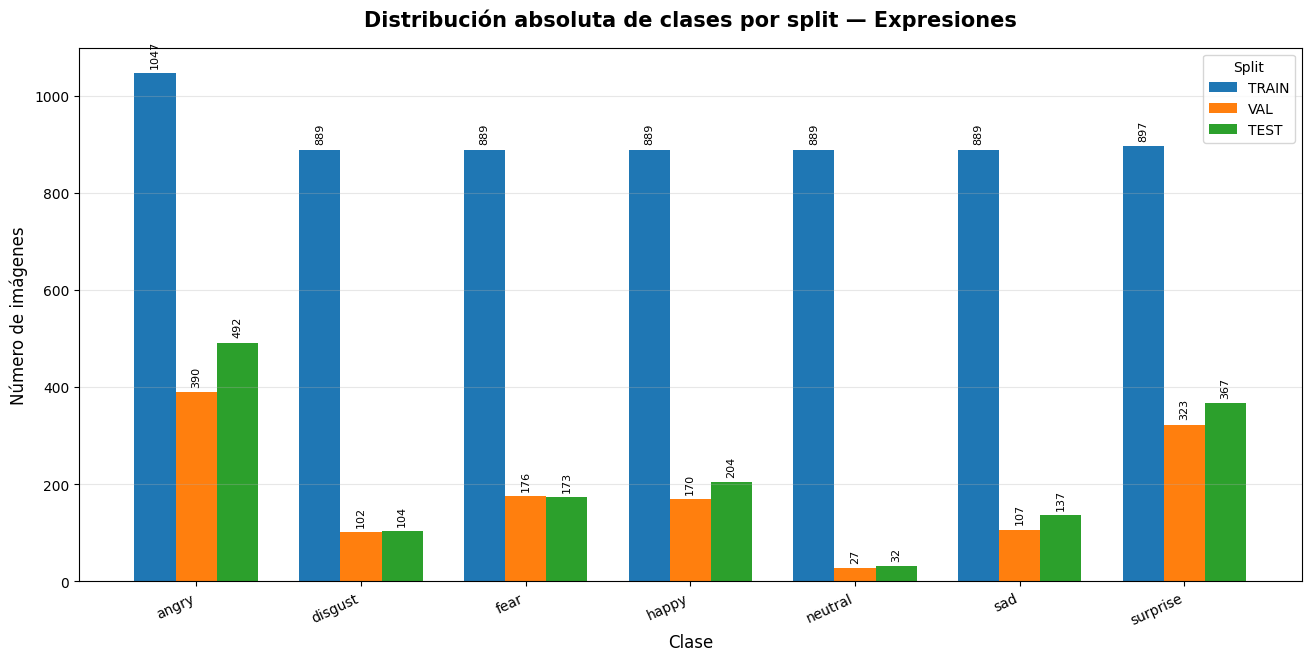

✅ Barras absolutas guardadas en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_distribucion_clases_barras_absolutas_expresiones.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_distribucion_clases_barras_absolutas_expresiones.pdf


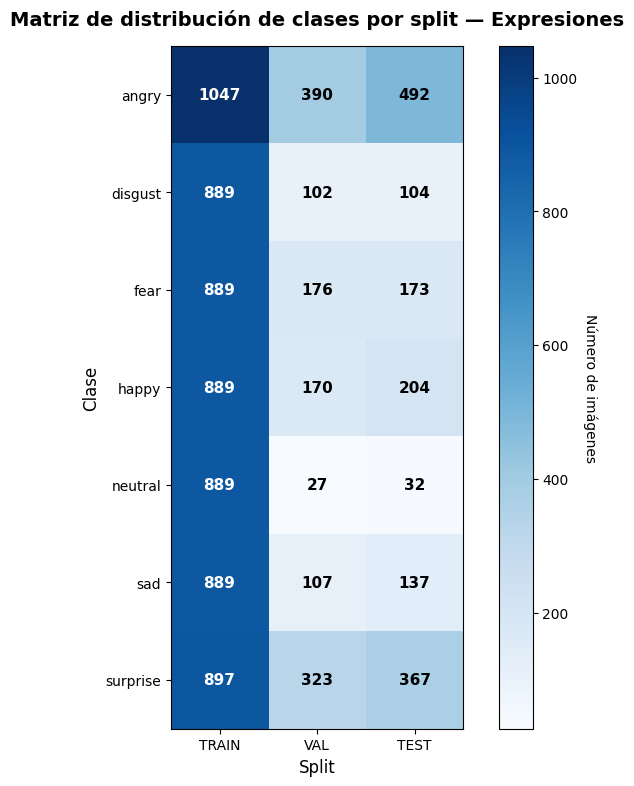

✅ Heatmap absoluto guardado en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_matriz_distribucion_clases_absoluta_expresiones.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_matriz_distribucion_clases_absoluta_expresiones.pdf


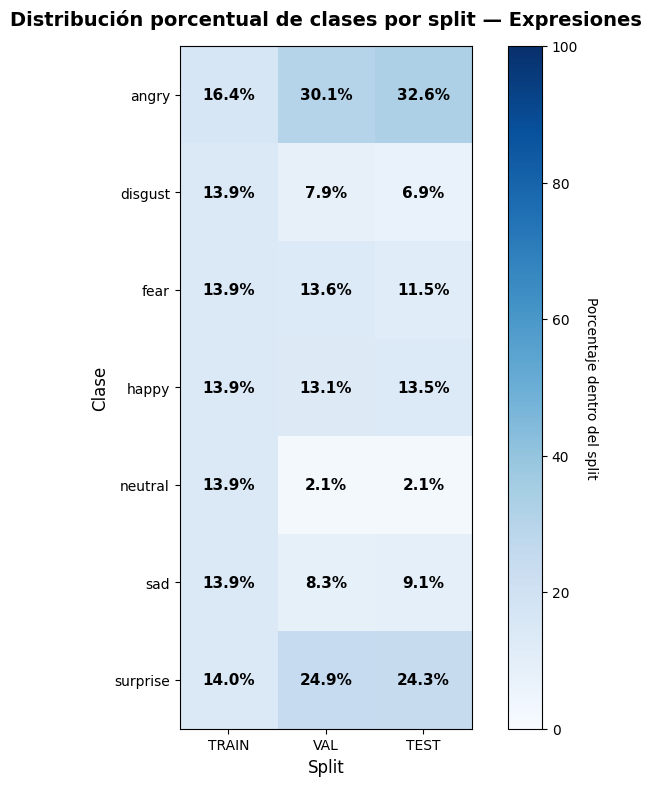

✅ Heatmap porcentual guardado en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_matriz_distribucion_clases_porcentual_expresiones.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_matriz_distribucion_clases_porcentual_expresiones.pdf

✅ DISTRIBUCIÓN DE CLASES GENERADA PARA EXPRESIONES
Archivos principales:
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/tabla_distribucion_clases_absoluta_expresiones.csv
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/tabla_distribucion_clases_porcentual_expresiones.csv
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_distribucion_clases_barras_absolutas_expresiones.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_matriz_distribucion_clases_absoluta_expresiones.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_matriz_distribucion_clases_porcentual_expresiones.png


In [21]:
# ============================================================
# CELDA 13 – Distribución de clases por split: barras + heatmap
# Proyecto: Reconocimiento de expresiones con YOLOv8n
#
# Esta versión:
#   - NO depende de variables previas.
#   - NO usa YOLO_DATASET, CLASS_NAMES, NUM_CLASSES ni SPLITS heredados.
#   - Lee las clases directamente desde data.yaml.
#   - Valida que NO se estén usando clases de caídas.
#   - Genera:
#       1. Tabla absoluta
#       2. Tabla porcentual
#       3. Barras absolutas
#       4. Heatmap absoluto
#       5. Heatmap porcentual
#
# No entrena.
# No predice.
# No modifica el dataset.
# Solo lee labels y guarda figuras.
# ============================================================

from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yaml

# ------------------------------------------------------------
# 1. Rutas correctas del proyecto de EXPRESIONES
# ------------------------------------------------------------

MYDRIVE = Path("/content/drive/MyDrive")
TFM_DIR = MYDRIVE / "TFM"

DATASET_DIR = TFM_DIR / "EXPRESIONES" / "YOLO_EXPRESIONES_UNIFIED"
DATA_YAML = DATASET_DIR / "data.yaml"

FIG_DIR = TFM_DIR / "figuras_resultados_yolo_expresiones"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "val", "test"]
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("=" * 70)
print("📊 DISTRIBUCIÓN DE CLASES POR SPLIT - EXPRESIONES")
print("=" * 70)

print("DATASET_DIR:", DATASET_DIR)
print("Existe?    :", DATASET_DIR.exists())
print("DATA_YAML  :", DATA_YAML)
print("Existe?    :", DATA_YAML.exists())
print("FIG_DIR    :", FIG_DIR)

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"No se encontró el dataset de expresiones en:\n{DATASET_DIR}")

if not DATA_YAML.exists():
    raise FileNotFoundError(f"No se encontró data.yaml en:\n{DATA_YAML}")

# ------------------------------------------------------------
# 2. Leer clases desde data.yaml
# ------------------------------------------------------------

def normalizar_names(names):
    """
    Convierte la sección names del data.yaml a una lista ordenada.
    Soporta:
      names: ['angry', 'disgust', ...]
      names: {0: 'angry', 1: 'disgust', ...}
      names: {'0': 'angry', '1': 'disgust', ...}
    """
    if isinstance(names, list):
        return names

    if isinstance(names, dict):
        return [names[k] for k in sorted(names, key=lambda x: int(x))]

    raise ValueError("No se pudo interpretar la sección 'names' del data.yaml.")


with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = normalizar_names(data_yaml.get("names"))
NUM_CLASSES = len(CLASS_NAMES)

print("\n🎭 Clases detectadas desde data.yaml:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

CLASES_ESPERADAS = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

if CLASS_NAMES != CLASES_ESPERADAS:
    raise ValueError(
        "⚠️ Las clases detectadas no coinciden con el proyecto de expresiones.\n"
        f"Detectadas: {CLASS_NAMES}\n"
        f"Esperadas : {CLASES_ESPERADAS}"
    )

# Seguridad extra: detener si aparecen clases de caídas
if "fall" in CLASS_NAMES or "non_fall" in CLASS_NAMES:
    raise ValueError(
        "⚠️ Se detectaron clases de caídas en esta celda. "
        "No corresponde al proyecto de expresiones."
    )

# ------------------------------------------------------------
# 3. Funciones auxiliares
# ------------------------------------------------------------

def leer_clases_yolo(lbl_path):
    """
    Lee un archivo .txt en formato YOLO y devuelve las clases encontradas.

    Cada línea del label debe tener:
        class_id x_center y_center width height

    Retorna:
        lista de class_id válidos.
    """

    clases = []

    try:
        with open(lbl_path, "r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                parts = line.strip().split()

                if len(parts) == 5:
                    try:
                        cid = int(float(parts[0]))

                        if 0 <= cid < NUM_CLASSES:
                            clases.append(cid)

                    except Exception:
                        pass

    except Exception:
        pass

    return clases


def clase_dominante(lbl_path):
    """
    Devuelve la clase dominante de una imagen según su archivo label.

    Para una imagen con una sola anotación, devuelve esa clase.
    Para una imagen con varias anotaciones, devuelve la clase más frecuente.
    Si no hay clases válidas, devuelve None.
    """

    clases = leer_clases_yolo(lbl_path)

    if not clases:
        return None

    return max(set(clases), key=clases.count)

# ------------------------------------------------------------
# 4. Conteo por split y clase dominante
# ------------------------------------------------------------

conteo = {s: Counter() for s in SPLITS}

resumen_archivos = []

for split in SPLITS:
    img_dir = DATASET_DIR / "images" / split
    lbl_dir = DATASET_DIR / "labels" / split

    imgs = sorted([
        p for p in img_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ]) if img_dir.exists() else []

    lbls = sorted([
        p for p in lbl_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    ]) if lbl_dir.exists() else []

    img_stems = {p.stem for p in imgs}
    lbl_stems = {p.stem for p in lbls}

    imgs_sin_label = img_stems - lbl_stems
    labels_sin_img = lbl_stems - img_stems

    labels_sin_clase = 0

    for lbl in lbls:
        c = clase_dominante(lbl)

        if c is not None:
            conteo[split][c] += 1
        else:
            labels_sin_clase += 1

    resumen_archivos.append({
        "split": split,
        "imagenes": len(imgs),
        "labels": len(lbls),
        "imagenes_sin_label": len(imgs_sin_label),
        "labels_sin_imagen": len(labels_sin_img),
        "labels_sin_clase_valida": labels_sin_clase
    })

df_resumen_archivos = pd.DataFrame(resumen_archivos)

print("\n📋 Revisión de archivos por split:")
display(df_resumen_archivos)

# ------------------------------------------------------------
# 5. Construir tabla absoluta
# ------------------------------------------------------------

tabla_abs = pd.DataFrame(
    {
        s: [conteo[s].get(i, 0) for i in range(NUM_CLASSES)]
        for s in SPLITS
    },
    index=CLASS_NAMES
)

print("\n📋 Distribución absoluta:")
display(tabla_abs)

# Guardar tabla absoluta
OUT_TABLA_ABS = FIG_DIR / "tabla_distribucion_clases_absoluta_expresiones.csv"
tabla_abs.to_csv(OUT_TABLA_ABS)

print("✅ Tabla absoluta guardada en:")
print(OUT_TABLA_ABS)

# ------------------------------------------------------------
# 6. Construir tabla porcentual por split
# ------------------------------------------------------------

tabla_pct = tabla_abs.copy().astype(float)

for s in SPLITS:
    total_split = tabla_pct[s].sum()

    if total_split > 0:
        tabla_pct[s] = 100 * tabla_pct[s] / total_split
    else:
        tabla_pct[s] = 0

print("\n📋 Distribución porcentual dentro de cada split:")
display(tabla_pct.round(2))

OUT_TABLA_PCT = FIG_DIR / "tabla_distribucion_clases_porcentual_expresiones.csv"
tabla_pct.to_csv(OUT_TABLA_PCT)

print("✅ Tabla porcentual guardada en:")
print(OUT_TABLA_PCT)

# ------------------------------------------------------------
# 7. Gráfica de barras absolutas
# ------------------------------------------------------------

x = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6.5), constrained_layout=True)

max_val = max(1, tabla_abs.values.max())

for i, split in enumerate(SPLITS):
    vals = tabla_abs[split].values

    barras = ax.bar(
        x + (i - 1) * width,
        vals,
        width,
        label=split.upper()
    )

    for b, v in zip(barras, vals):
        if v > 0:
            ax.text(
                b.get_x() + b.get_width() / 2,
                v + max_val * 0.01,
                f"{int(v)}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90
            )

ax.set_title(
    "Distribución absoluta de clases por split — Expresiones",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Clase", fontsize=12)
ax.set_ylabel("Número de imágenes", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right", fontsize=10)
ax.legend(title="Split")
ax.grid(axis="y", alpha=0.3)

OUT_ABS_PNG = FIG_DIR / "fig_distribucion_clases_barras_absolutas_expresiones.png"
OUT_ABS_PDF = FIG_DIR / "fig_distribucion_clases_barras_absolutas_expresiones.pdf"

plt.savefig(OUT_ABS_PNG, dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.savefig(OUT_ABS_PDF, bbox_inches="tight", pad_inches=0.25)
plt.show()

print("✅ Barras absolutas guardadas en:")
print(OUT_ABS_PNG)
print(OUT_ABS_PDF)

# ------------------------------------------------------------
# 8. Heatmap absoluto
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.5, 0.75 * NUM_CLASSES + 2.5), constrained_layout=True)

mat_abs = tabla_abs.values

im = ax.imshow(mat_abs, cmap="Blues")

ax.set_title(
    "Matriz de distribución de clases por split — Expresiones",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xticks(np.arange(len(SPLITS)))
ax.set_yticks(np.arange(NUM_CLASSES))

ax.set_xticklabels([s.upper() for s in SPLITS])
ax.set_yticklabels(CLASS_NAMES)

for i in range(mat_abs.shape[0]):
    for j in range(mat_abs.shape[1]):
        v = int(mat_abs[i, j])

        ax.text(
            j,
            i,
            f"{v}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="white" if v > mat_abs.max() * 0.55 else "black"
        )

cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Número de imágenes", rotation=-90, va="bottom")

ax.set_xlabel("Split", fontsize=12)
ax.set_ylabel("Clase", fontsize=12)

OUT_HEAT_ABS_PNG = FIG_DIR / "fig_matriz_distribucion_clases_absoluta_expresiones.png"
OUT_HEAT_ABS_PDF = FIG_DIR / "fig_matriz_distribucion_clases_absoluta_expresiones.pdf"

plt.savefig(OUT_HEAT_ABS_PNG, dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.savefig(OUT_HEAT_ABS_PDF, bbox_inches="tight", pad_inches=0.25)
plt.show()

print("✅ Heatmap absoluto guardado en:")
print(OUT_HEAT_ABS_PNG)
print(OUT_HEAT_ABS_PDF)

# ------------------------------------------------------------
# 9. Heatmap porcentual
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.5, 0.75 * NUM_CLASSES + 2.5), constrained_layout=True)

mat_pct = tabla_pct.values

im = ax.imshow(mat_pct, cmap="Blues", vmin=0, vmax=100)

ax.set_title(
    "Distribución porcentual de clases por split — Expresiones",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xticks(np.arange(len(SPLITS)))
ax.set_yticks(np.arange(NUM_CLASSES))

ax.set_xticklabels([s.upper() for s in SPLITS])
ax.set_yticklabels(CLASS_NAMES)

for i in range(mat_pct.shape[0]):
    for j in range(mat_pct.shape[1]):
        v = mat_pct[i, j]

        ax.text(
            j,
            i,
            f"{v:.1f}%",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="white" if v > 55 else "black"
        )

cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Porcentaje dentro del split", rotation=-90, va="bottom")

ax.set_xlabel("Split", fontsize=12)
ax.set_ylabel("Clase", fontsize=12)

OUT_HEAT_PCT_PNG = FIG_DIR / "fig_matriz_distribucion_clases_porcentual_expresiones.png"
OUT_HEAT_PCT_PDF = FIG_DIR / "fig_matriz_distribucion_clases_porcentual_expresiones.pdf"

plt.savefig(OUT_HEAT_PCT_PNG, dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.savefig(OUT_HEAT_PCT_PDF, bbox_inches="tight", pad_inches=0.25)
plt.show()

print("✅ Heatmap porcentual guardado en:")
print(OUT_HEAT_PCT_PNG)
print(OUT_HEAT_PCT_PDF)

# ------------------------------------------------------------
# 10. Resumen final
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ DISTRIBUCIÓN DE CLASES GENERADA PARA EXPRESIONES")
print("=" * 70)

print("Archivos principales:")
print(OUT_TABLA_ABS)
print(OUT_TABLA_PCT)
print(OUT_ABS_PNG)
print(OUT_HEAT_ABS_PNG)
print(OUT_HEAT_PCT_PNG)

## 📉 Sección 14 – Curvas de entrenamiento (a partir de `results.csv`)

📈 CURVAS DE MÉTRICAS Y PÉRDIDAS - EXPRESIONES
DATASET_DIR_EXP: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
Existe?        : True
DATA_YAML_EXP  : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/data.yaml
Existe?        : True
RUN_DIR_EXP    : /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones
Existe?        : True
RESULTS_CSV_EXP: /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones/results.csv
Existe?        : True
FIG_DIR_EXP    : /content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones

🎭 Clases detectadas desde data.yaml:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise
✅ data.yaml corresponde al proyecto de expresiones.

📄 args.yaml encontrado. Validando entrenamiento...
data usada en entrenamiento: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/data.yaml

📋 Columnas disponibles en results.csv:
 - epoch
 - time
 - train/box_loss
 - train/cl

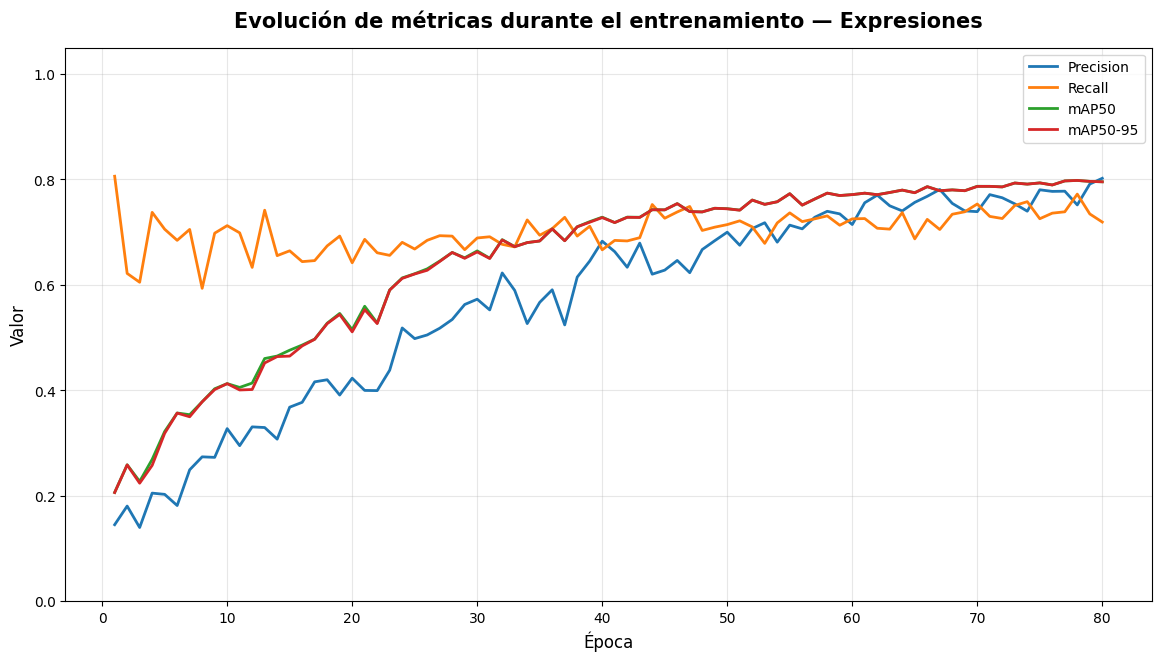

✅ Curva de métricas guardada en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_curva_metricas_entrenamiento_expresiones.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_curva_metricas_entrenamiento_expresiones.pdf


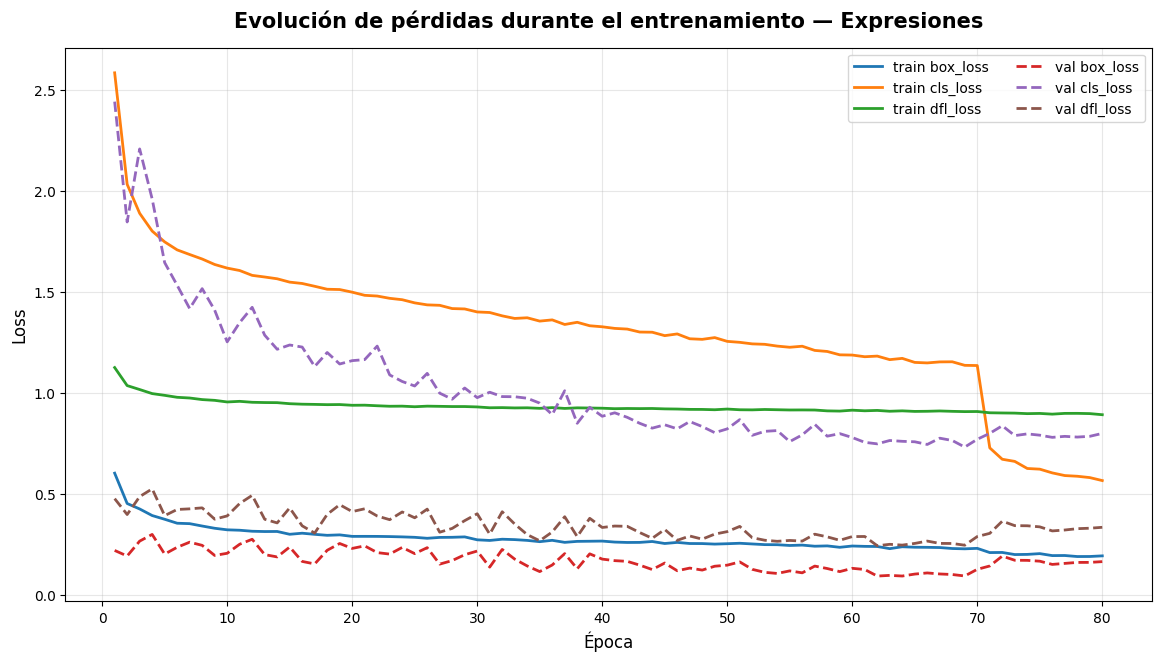

✅ Curva de pérdidas guardada en:
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_curva_perdidas_entrenamiento_expresiones.png
/content/drive/MyDrive/TFM/figuras_resultados_yolo_expresiones/fig_curva_perdidas_entrenamiento_expresiones.pdf

✅ CELDA 14 completada para EXPRESIONES.


In [22]:
# ============================================================
# CELDA 14 – Curvas de métricas y pérdidas del entrenamiento
# Proyecto: Reconocimiento de expresiones con YOLOv8n
#
# Esta versión:
#   - NO depende de TFM_DIR, PROJECT_DIR ni RUN_NAME previos.
#   - Lee únicamente el results.csv del proyecto EXPRESIONES.
#   - Valida que la ruta no sea de caídas.
#   - Valida que data.yaml tenga las clases de expresiones.
#   - Genera:
#       1. Curva de métricas por época
#       2. Curva de pérdidas train vs val
#
# No entrena.
# No predice.
# Solo lee results.csv y guarda figuras.
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# ------------------------------------------------------------
# 1. Rutas explícitas del proyecto de EXPRESIONES
# ------------------------------------------------------------

MYDRIVE = Path("/content/drive/MyDrive")
TFM_DIR_EXP = MYDRIVE / "TFM"

DATASET_DIR_EXP = TFM_DIR_EXP / "EXPRESIONES" / "YOLO_EXPRESIONES_UNIFIED"
DATA_YAML_EXP = DATASET_DIR_EXP / "data.yaml"

PROJECT_DIR_EXP = TFM_DIR_EXP / "runs_yolo_expresiones"
RUN_NAME_EXP = "baseline_yolov8n_expresiones"
RUN_DIR_EXP = PROJECT_DIR_EXP / RUN_NAME_EXP

RESULTS_CSV_EXP = RUN_DIR_EXP / "results.csv"
ARGS_YAML_EXP = RUN_DIR_EXP / "args.yaml"

FIG_DIR_EXP = TFM_DIR_EXP / "figuras_resultados_yolo_expresiones"
FIG_DIR_EXP.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("📈 CURVAS DE MÉTRICAS Y PÉRDIDAS - EXPRESIONES")
print("=" * 70)

print("DATASET_DIR_EXP:", DATASET_DIR_EXP)
print("Existe?        :", DATASET_DIR_EXP.exists())
print("DATA_YAML_EXP  :", DATA_YAML_EXP)
print("Existe?        :", DATA_YAML_EXP.exists())
print("RUN_DIR_EXP    :", RUN_DIR_EXP)
print("Existe?        :", RUN_DIR_EXP.exists())
print("RESULTS_CSV_EXP:", RESULTS_CSV_EXP)
print("Existe?        :", RESULTS_CSV_EXP.exists())
print("FIG_DIR_EXP    :", FIG_DIR_EXP)

# ------------------------------------------------------------
# 2. Validaciones de seguridad para no mezclar con caídas
# ------------------------------------------------------------

rutas_concatenadas = " ".join([
    str(DATASET_DIR_EXP),
    str(DATA_YAML_EXP),
    str(PROJECT_DIR_EXP),
    str(RUN_DIR_EXP),
    str(RESULTS_CSV_EXP),
    str(FIG_DIR_EXP)
]).lower()

if "caidas" in rutas_concatenadas or "baokhang" in rutas_concatenadas:
    raise ValueError(
        "⚠️ Se detectaron rutas del proyecto de caídas. "
        "Esta celda debe usarse solo para EXPRESIONES."
    )

if "expresiones" not in rutas_concatenadas:
    raise ValueError(
        "⚠️ No se detectó 'expresiones' en las rutas principales. "
        "Revisa que estés en el notebook correcto."
    )

if not DATA_YAML_EXP.exists():
    raise FileNotFoundError(f"No se encontró data.yaml:\n{DATA_YAML_EXP}")

if not RESULTS_CSV_EXP.exists():
    raise FileNotFoundError(
        f"No se encontró results.csv del entrenamiento de expresiones:\n{RESULTS_CSV_EXP}"
    )

# ------------------------------------------------------------
# 3. Validar clases desde data.yaml
# ------------------------------------------------------------

def normalizar_names(names):
    """
    Convierte names del data.yaml en lista ordenada.
    Soporta lista o diccionario.
    """
    if isinstance(names, list):
        return names

    if isinstance(names, dict):
        return [names[k] for k in sorted(names, key=lambda x: int(x))]

    raise ValueError("No se pudo interpretar la sección 'names' del data.yaml.")


with open(DATA_YAML_EXP, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES_EXP = normalizar_names(data_yaml.get("names"))

CLASES_ESPERADAS_EXP = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

print("\n🎭 Clases detectadas desde data.yaml:")
for i, name in enumerate(CLASS_NAMES_EXP):
    print(f"  {i}: {name}")

if CLASS_NAMES_EXP != CLASES_ESPERADAS_EXP:
    raise ValueError(
        "⚠️ Las clases detectadas no coinciden con expresiones.\n"
        f"Detectadas: {CLASS_NAMES_EXP}\n"
        f"Esperadas : {CLASES_ESPERADAS_EXP}"
    )

print("✅ data.yaml corresponde al proyecto de expresiones.")

# ------------------------------------------------------------
# 4. Validar args.yaml del entrenamiento, si existe
# ------------------------------------------------------------

if ARGS_YAML_EXP.exists():
    print("\n📄 args.yaml encontrado. Validando entrenamiento...")

    with open(ARGS_YAML_EXP, "r", encoding="utf-8") as f:
        args_yaml = yaml.safe_load(f)

    data_usada = str(args_yaml.get("data", "")).lower()
    print("data usada en entrenamiento:", args_yaml.get("data", ""))

    if "caidas" in data_usada or "baokhang" in data_usada:
        raise ValueError(
            "⚠️ El args.yaml del entrenamiento apunta a datos de caídas. "
            "No uses este results.csv para expresiones."
        )

    if "expresiones" not in data_usada:
        print(
            "⚠️ Advertencia: args.yaml no contiene explícitamente la palabra 'expresiones'. "
            "Se continuará porque las rutas principales y data.yaml sí corresponden a expresiones."
        )
else:
    print("\n⚠️ No se encontró args.yaml. Se continuará validando con rutas y data.yaml.")

# ------------------------------------------------------------
# 5. Cargar results.csv
# ------------------------------------------------------------

dfh = pd.read_csv(RESULTS_CSV_EXP)

# Limpiar espacios en nombres de columnas
dfh.columns = [c.strip() for c in dfh.columns]

print("\n📋 Columnas disponibles en results.csv:")
for c in dfh.columns:
    print(" -", c)

if "epoch" in dfh.columns:
    epochs = dfh["epoch"]
else:
    epochs = range(1, len(dfh) + 1)

print(f"\nTotal de épocas registradas: {len(dfh)}")

# ------------------------------------------------------------
# 6. Función auxiliar para obtener columnas
# ------------------------------------------------------------

def col(name):
    return dfh[name] if name in dfh.columns else None

# ------------------------------------------------------------
# 7. Curva de métricas por época
# ------------------------------------------------------------

metricas = [
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)", "Recall"),
    ("metrics/mAP50(B)", "mAP50"),
    ("metrics/mAP50-95(B)", "mAP50-95"),
]

metricas_disponibles = [(c, lab) for c, lab in metricas if c in dfh.columns]

if len(metricas_disponibles) == 0:
    print("⚠️ No se encontraron columnas de métricas en results.csv.")
else:
    fig, ax = plt.subplots(figsize=(11.5, 6.5), constrained_layout=True)

    for c, lab in metricas_disponibles:
        ax.plot(
            epochs,
            dfh[c],
            linewidth=2,
            label=lab
        )

    ax.set_title(
        "Evolución de métricas durante el entrenamiento — Expresiones",
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("Época", fontsize=12)
    ax.set_ylabel("Valor", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend()

    OUT_METRICAS_PNG = FIG_DIR_EXP / "fig_curva_metricas_entrenamiento_expresiones.png"
    OUT_METRICAS_PDF = FIG_DIR_EXP / "fig_curva_metricas_entrenamiento_expresiones.pdf"

    plt.savefig(OUT_METRICAS_PNG, dpi=300, bbox_inches="tight", pad_inches=0.25)
    plt.savefig(OUT_METRICAS_PDF, bbox_inches="tight", pad_inches=0.25)
    plt.show()

    print("✅ Curva de métricas guardada en:")
    print(OUT_METRICAS_PNG)
    print(OUT_METRICAS_PDF)

# ------------------------------------------------------------
# 8. Curva de pérdidas train vs val
# ------------------------------------------------------------

perdidas = [
    ("train/box_loss", "train box_loss"),
    ("train/cls_loss", "train cls_loss"),
    ("train/dfl_loss", "train dfl_loss"),
    ("val/box_loss", "val box_loss"),
    ("val/cls_loss", "val cls_loss"),
    ("val/dfl_loss", "val dfl_loss"),
]

perdidas_disponibles = [(c, lab) for c, lab in perdidas if c in dfh.columns]

if len(perdidas_disponibles) == 0:
    print("⚠️ No se encontraron columnas de pérdidas en results.csv.")
else:
    fig, ax = plt.subplots(figsize=(11.5, 6.5), constrained_layout=True)

    for c, lab in perdidas_disponibles:
        estilo = "--" if c.startswith("val") else "-"

        ax.plot(
            epochs,
            dfh[c],
            estilo,
            linewidth=2,
            label=lab
        )

    ax.set_title(
        "Evolución de pérdidas durante el entrenamiento — Expresiones",
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("Época", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(ncol=2)

    OUT_LOSS_PNG = FIG_DIR_EXP / "fig_curva_perdidas_entrenamiento_expresiones.png"
    OUT_LOSS_PDF = FIG_DIR_EXP / "fig_curva_perdidas_entrenamiento_expresiones.pdf"

    plt.savefig(OUT_LOSS_PNG, dpi=300, bbox_inches="tight", pad_inches=0.25)
    plt.savefig(OUT_LOSS_PDF, bbox_inches="tight", pad_inches=0.25)
    plt.show()

    print("✅ Curva de pérdidas guardada en:")
    print(OUT_LOSS_PNG)
    print(OUT_LOSS_PDF)

print("\n✅ CELDA 14 completada para EXPRESIONES.")

## 🧹 Sección 15 – Liberar memoria GPU / RAM

In [17]:
# ============================================================
# CELDA 15 – Liberar memoria GPU y RAM
# ============================================================
import gc, torch

print("=" * 70)
for v in ["model", "model_best", "results", "pred_results", "metrics_test"]:
    if v in globals():
        del globals()[v]
        print(f"🗑️  Eliminado: {v}")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"🔥 VRAM reservada tras limpieza: {torch.cuda.memory_reserved(0)/1024**2:.0f} MB")
print("✅ Memoria liberada.")


🔥 VRAM reservada tras limpieza: 0 MB
✅ Memoria liberada.


## 🔐 Sección 16 – Auditoría final de integridad (solo lectura)

In [18]:
# ============================================================
# CELDA 16 – Auditoría final de integridad del proyecto
# Proyecto: Reconocimiento de expresiones con YOLOv8n
#
# NO entrena.
# NO predice.
# NO borra.
# NO mueve archivos.
# NO crea carpetas.
# Solo lectura.
# ============================================================

from pathlib import Path
from collections import Counter
import pandas as pd
import yaml

print("=" * 70)
print("🔐 AUDITORÍA FINAL DEL PROYECTO DE EXPRESIONES")
print("=" * 70)

# ------------------------------------------------------------
# 1. Definir rutas correctas del proyecto de EXPRESIONES
# ------------------------------------------------------------

MYDRIVE = Path("/content/drive/MyDrive")
TFM_DIR = MYDRIVE / "TFM"

DATASET_DIR = TFM_DIR / "EXPRESIONES" / "YOLO_EXPRESIONES_UNIFIED"
DATA_YAML = DATASET_DIR / "data.yaml"

PROJECT_DIR = TFM_DIR / "runs_yolo_expresiones"
RUN_NAME = "baseline_yolov8n_expresiones"
RUN_DIR = PROJECT_DIR / RUN_NAME

BEST_MODEL = RUN_DIR / "weights" / "best.pt"
LAST_MODEL = RUN_DIR / "weights" / "last.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

TEST_EVAL_DIR = PROJECT_DIR / f"{RUN_NAME}_test_eval"

FIG_DIR = TFM_DIR / "figuras_resultados_yolo_expresiones"
PRED_DIR = TFM_DIR / "predicciones_yolo_expresiones" / "test_visual_baseline_yolov8n"

SPLITS = ["train", "val", "test"]
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

CLASS_NAMES = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

CLASES_VALIDAS = set(range(len(CLASS_NAMES)))

print("\n📌 Rutas configuradas:")
print("DATASET_DIR  :", DATASET_DIR)
print("DATA_YAML    :", DATA_YAML)
print("PROJECT_DIR  :", PROJECT_DIR)
print("RUN_DIR      :", RUN_DIR)
print("TEST_EVAL_DIR:", TEST_EVAL_DIR)

# ------------------------------------------------------------
# 2. Artefactos principales
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("📋 ARTEFACTOS PRINCIPALES")
print("=" * 70)

checks = {
    "dataset expresiones": DATASET_DIR,
    "data.yaml": DATA_YAML,
    "carpeta runs": PROJECT_DIR,
    "carpeta entrenamiento": RUN_DIR,
    "best.pt": BEST_MODEL,
    "last.pt": LAST_MODEL,
    "results.csv": RESULTS_CSV,
    "carpeta eval TEST": TEST_EVAL_DIR,
    "matriz confusión": TEST_EVAL_DIR / "confusion_matrix.png",
    "matriz confusión normalizada": TEST_EVAL_DIR / "confusion_matrix_normalized.png",
    "resumen métricas CSV": TEST_EVAL_DIR / "metricas_test_resumen.csv",
    "carpeta figuras": FIG_DIR,
    "carpeta predicciones": PRED_DIR,
}

for nombre, ruta in checks.items():
    marca = "✅" if ruta.exists() else "❌"
    print(f"{marca} {nombre:<32} → {ruta}")

# ------------------------------------------------------------
# 3. Leer data.yaml
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("📄 CONTENIDO DE data.yaml")
print("=" * 70)

if DATA_YAML.exists():
    with open(DATA_YAML, "r", encoding="utf-8") as f:
        data_yaml = yaml.safe_load(f)

    for k, v in data_yaml.items():
        print(f"{k}: {v}")

    print("\nClases detectadas en data.yaml:")
    names_yaml = data_yaml.get("names", [])

    if isinstance(names_yaml, dict):
        for k, v in names_yaml.items():
            print(f"  {k}: {v}")
    else:
        for i, name in enumerate(names_yaml):
            print(f"  {i}: {name}")
else:
    print("❌ No se encontró data.yaml.")

# ------------------------------------------------------------
# 4. Función para leer labels YOLO
# ------------------------------------------------------------

def leer_clases_label(label_path):
    """
    Lee un archivo .txt en formato YOLO y devuelve:
    - clases encontradas
    - errores detectados
    """
    clases = []
    errores = []

    if not label_path.exists():
        return clases, ["label_no_existe"]

    try:
        with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
            lineas = f.readlines()
    except Exception as e:
        return clases, [f"error_lectura_{e}"]

    if len(lineas) == 0:
        return clases, ["label_vacio"]

    for i, line in enumerate(lineas, start=1):
        partes = line.strip().split()

        if len(partes) != 5:
            errores.append(f"linea_{i}_formato_invalido")
            continue

        try:
            cid = int(float(partes[0]))
            x, y, w, h = map(float, partes[1:])

            if cid not in CLASES_VALIDAS:
                errores.append(f"linea_{i}_clase_invalida_{cid}")

            if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                errores.append(f"linea_{i}_bbox_fuera_rango")

            if w <= 0 or h <= 0:
                errores.append(f"linea_{i}_bbox_dimension_invalida")

            clases.append(cid)

        except Exception:
            errores.append(f"linea_{i}_conversion_invalida")

    return clases, errores

# ------------------------------------------------------------
# 5. Auditoría de imágenes y labels por split
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("📊 IMÁGENES Y LABELS POR SPLIT")
print("=" * 70)

resumen = []

if not DATASET_DIR.exists():
    print("❌ No se encontró el dataset de expresiones.")
else:
    for split in SPLITS:
        img_dir = DATASET_DIR / "images" / split
        lbl_dir = DATASET_DIR / "labels" / split

        imgs = sorted([
            p for p in img_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMG_EXTS
        ]) if img_dir.exists() else []

        lbls = sorted([
            p for p in lbl_dir.iterdir()
            if p.is_file() and p.suffix.lower() == ".txt"
        ]) if lbl_dir.exists() else []

        img_stems = {p.stem for p in imgs}
        lbl_stems = {p.stem for p in lbls}

        imgs_sin_label = img_stems - lbl_stems
        labels_sin_img = lbl_stems - img_stems

        conteo_clases = Counter()
        labels_vacios = 0
        labels_con_error = 0
        labels_sin_clase_valida = 0
        ejemplos_errores = []

        for lbl in lbls:
            clases, errores = leer_clases_label(lbl)

            if "label_vacio" in errores:
                labels_vacios += 1

            if errores:
                labels_con_error += 1
                if len(ejemplos_errores) < 5:
                    ejemplos_errores.append((lbl.name, errores))

            clases_validas = [c for c in clases if c in CLASES_VALIDAS]

            if len(clases_validas) == 0:
                labels_sin_clase_valida += 1
            else:
                # En detección YOLO puede haber más de una caja por imagen.
                # Se cuentan todas las instancias anotadas.
                for c in clases_validas:
                    conteo_clases[c] += 1

        print(f"\nSplit: {split.upper()}")
        print(f"  {'✅' if img_dir.exists() else '❌'} carpeta imágenes: {img_dir}")
        print(f"  {'✅' if lbl_dir.exists() else '❌'} carpeta labels  : {lbl_dir}")
        print(f"  imágenes: {len(imgs):,}")
        print(f"  labels  : {len(lbls):,}")
        print(f"  imágenes sin label: {len(imgs_sin_label):,}")
        print(f"  labels sin imagen : {len(labels_sin_img):,}")
        print(f"  labels vacíos: {labels_vacios:,}")
        print(f"  labels sin clase válida: {labels_sin_clase_valida:,}")
        print(f"  labels con errores: {labels_con_error:,}")

        print("  distribución de instancias por clase:")
        for cid, cname in enumerate(CLASS_NAMES):
            print(f"    {cid} - {cname:<10}: {conteo_clases[cid]:,}")

        if ejemplos_errores:
            print("  Ejemplos de errores:")
            for nombre_lbl, errores in ejemplos_errores:
                print(f"    - {nombre_lbl}: {errores}")

        resumen.append({
            "split": split,
            "imagenes": len(imgs),
            "labels": len(lbls),
            "imagenes_sin_label": len(imgs_sin_label),
            "labels_sin_imagen": len(labels_sin_img),
            "labels_vacios": labels_vacios,
            "labels_sin_clase_valida": labels_sin_clase_valida,
            "labels_con_error": labels_con_error,
            **{CLASS_NAMES[cid]: conteo_clases[cid] for cid in range(len(CLASS_NAMES))}
        })

# ------------------------------------------------------------
# 6. Aumentaciones fuera de train
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🧪 AUMENTACIONES FUERA DE TRAIN")
print("=" * 70)

for split in ["val", "test"]:
    img_dir = DATASET_DIR / "images" / split

    if img_dir.exists():
        aug_imgs = list(img_dir.glob("aug_*"))
        print(f"{split.upper():<5}: aug images = {len(aug_imgs):,} {'⚠️ REVISAR' if aug_imgs else '✅ OK'}")
    else:
        print(f"{split.upper():<5}: carpeta no visible")

# ------------------------------------------------------------
# 7. Resumen final
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("📌 RESUMEN FINAL")
print("=" * 70)

if len(resumen) > 0:
    df_resumen = pd.DataFrame(resumen)
    display(df_resumen)

    condiciones_basicas = (
        (df_resumen["imagenes"] > 0).all()
        and (df_resumen["labels"] > 0).all()
        and (df_resumen["imagenes_sin_label"] == 0).all()
        and (df_resumen["labels_sin_imagen"] == 0).all()
        and (df_resumen["labels_sin_clase_valida"] == 0).all()
    )

    if condiciones_basicas:
        print("✅ Auditoría correcta: el dataset visible tiene imágenes, labels y correspondencia válida.")
        print("✅ No se detectan daños estructurales básicos en los splits train, val y test.")
    else:
        print("⚠️ Auditoría con alertas: revisar filas con valores distintos de cero en errores o desajustes.")
else:
    print("⚠️ No se pudo generar resumen porque el dataset no está visible.")

print("\n✅ Auditoría completada en modo solo lectura.")

🔐 AUDITORÍA FINAL DEL PROYECTO DE EXPRESIONES

📌 Rutas configuradas:
DATASET_DIR  : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
DATA_YAML    : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/data.yaml
PROJECT_DIR  : /content/drive/MyDrive/TFM/runs_yolo_expresiones
RUN_DIR      : /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones
TEST_EVAL_DIR: /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones_test_eval

📋 ARTEFACTOS PRINCIPALES
✅ dataset expresiones              → /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
✅ data.yaml                        → /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/data.yaml
✅ carpeta runs                     → /content/drive/MyDrive/TFM/runs_yolo_expresiones
✅ carpeta entrenamiento            → /content/drive/MyDrive/TFM/runs_yolo_expresiones/baseline_yolov8n_expresiones
✅ best.pt                          → /content/drive/MyDrive/TFM/

,split,imagenes,labels,imagenes_sin_label,labels_sin_imagen,labels_vacios,labels_sin_clase_valida,labels_con_error,angry,disgust,fear,happy,neutral,sad,surprise
0,train,11399,11399,0,0,0,5010,5010,1047,2193,1699,1729,2450,1998,897
1,val,2875,2875,0,0,0,1580,1580,390,102,176,170,27,107,323
2,test,3586,3586,0,0,0,2077,2077,492,104,173,204,32,137,367


⚠️ Auditoría con alertas: revisar filas con valores distintos de cero en errores o desajustes.

✅ Auditoría completada en modo solo lectura.


## 📝 Notas finales para la documentación

**Uso de los conjuntos.** El conjunto de *entrenamiento* ajusta los pesos del modelo;
el de *validación* monitorea el desempeño por época (Precision, Recall, mAP50, mAP50-95)
y dispara el *early stopping*; el de *prueba* se reserva para la evaluación final del
modelo ya entrenado.

**Interpretación de la matriz de confusión.** En la diagonal principal se concentran las
expresiones correctamente clasificadas. En un problema de 7 clases es esperable cierta
confusión entre expresiones visualmente cercanas (p. ej. `fear`↔`surprise` o `sad`↔`neutral`).
La fila/columna `background` corresponde a la representación interna de YOLO para falsos
positivos/negativos y **no es una octava clase** del problema.

**Continuidad.** Este notebook consume el dataset equilibrado que produjo
`TFM_EDA_YOLO_Expresiones.ipynb` y entrega: pesos (`best.pt`), métricas reales por clase,
matriz de confusión, curvas PR/F1/P/R, curvas de entrenamiento y las figuras listas para
el documento y la sustentación.
